# Combining Random Forest Classification and a Quasi-Experimental Approach to Evaluate 20 mph Zones’ Impact on Traffic Accident Severity in Central London: Roles of Job Density, Timing, and Vehicle Factors.
## CASA0006: Data Science for Spatial Systems
## Student ID: 24054679

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

[Introduction](#Introduction)

[Literature review](#Literature-review)

[Research questions](#Research-questions)

[Data](#Data)

[Methodology](#Methodology)

[Results and discussion](#Results-and-discussion)

[Conclusion](#Conclusion)

[References](#References)

## 1.Introduction

[[ go back to the top ]](#Table-of-contents)

<a id='intro'></a>
# Introduction
The notebook is an exploration of time-based trends in 2023 seen in [1.6 million UK traffic accidents][1] dataset. 

|dataset|description|
|---|---|
|[London traffic accidents][1]|Overviwe on Road safety|
|[London casualties Accidents][2]||
|[London Traffic Vehicles][3]||
|[London geo][4]||

The original dataset has 33 features describing each of the accidents recorded therein, where the attributes included describe things like
* the date and time of the accident
* the physical location of the accident
* the current weather conditions
* the severity of the accident

Here, we are going to focus simply on the date and time features, of which there are the following four

|feature|description|
|---|---|
|Date|formatted as DD/MM/YYYY|
|Time|formatted as HH:MM|
|Year|YYYY|
|Day_of_Week|1=Sun, 2=Mon, 3=Tue, 4=Wed, 5=Thu, 6=Fri, 7=Sat|


[1]:https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-accidents-safety-data
[2]:https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv
[3]:https://www.kaggle.com/datasets/silicon99/dft-accident-data
[4]:https://www.kaggle.com/silicon99
[5]:https://www.kaggle.com/datasets/tsiaras/uk-road-safety-accidents-and-vehicles
[6]:https://www.kaggle.com/tsiaras
[7]:https://www.kaggle.com/datasets/benoit72/uk-accidents-10-years-history-with-many-variables
[8]:https://www.kaggle.com/benoit72
[9]:https://www.kaggle.com/datasets/devansodariya/road-accident-united-kingdom-uk-dataset
[10]:https://www.kaggle.com/devansodariya

## 2.Literature review

[[ go back to the top ]](#Table-of-contents)

## 3.Research questions

[[ go back to the top ]](#Table-of-contents)

1. What appears in the traffic accident severity pattern, in areas across central London, can be related in some way with different factors like job densities, timings of accidents, and how the vehicles are like.  

2. These influencing factors, when seen together with others that could interfere such as how much traffic or how the weather is, are looked at to know their effects more fully. 

As it was already explained in the earlier part (Section 1), the situation has many variables, like how busy an area is (like jobs around), what time the accidents happen mostly, and vehicles being of various kinds, which may be having some important role in deciding how severe the accidents end up becoming. So, it can be said looking into how accidents are happening in space—like across places—and how these factors interact and cause the problem is something considered meaningful. 

The specific research objectives are:

1. **Spatial Distribution Analyzing**: Some investigations should look into how accidents are spread, especially inside central London and more precisely borough by borough. The places where more bad accidents take place, those need to be noticed and recorded, where they are happening more.  

2. **Looking Into Main Factors**: There is a need to study how things like job numbers in one area (urban activity), time when accidents happen (week or daily clock), and vehicle features (what type it is, how big or fast it might be) make the accident worse or not.  

3. **Confounding Influence Controlling**: Things that can confuse the observation like general traffic movements (how much traffic, what weather happens, morning or evening traffic time) are to be added, so it's not mistaken that just traffic amount is the real reason.  

4. **Suggestions Developing**: It would be helpful to write down certain practical things—such as where traffic should be slowed with calming systems, or some rules changed for vehicles—that can help make severe accidents fewer. These suggestions should be based on the locations and patterns seen, and what risks were found.

## 4.Data Description

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

### 4.1 Data Introduction

In [1]:
# All the packages used below have been downloaded already under this environment 
#if any package is missing please use the pip install command to install it. For example pip install pandas.
import pandas as pd
import geopandas as gpd
import numpy as np
import requests # for loading data from websites remotely
import contextily
from shapely.geometry import Point
from io import BytesIO, StringIO # deal with different file catelogies (csv or excel)
from scipy import stats # for descriptive statistics
from scipy.stats import zscore
import warnings # suppress the warning
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay)
from sklearn.neighbors import NearestNeighbors

#!pip install linearmodels
import plotly
import plotly.express as px
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col
from linearmodels import PanelOLS
from linearmodels import RandomEffects
import statsmodels.formula.api as smf
from linearmodels.panel import compare
import shap
from libpysal.weights import DistanceBand
from spglm.family import Binomial

warnings.filterwarnings('ignore')
sns.set(font_scale=1.5)
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 8)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**4.1.1 Loading the Data**

In [2]:
# function for loading the datasets file_format can be:'csv'/'excel'/'geopackage' (or 'gpkg') for geospatial data

def load_data(remote_url, local_path, file_format="csv", **kwargs):
    try:
        print(f"Attempting to load data from {remote_url} (format={file_format})")
        response = requests.get(remote_url)
        response.raise_for_status()
        if file_format.lower() in ["excel", "xlsx", "xls"]:
            # Read Excel from in-memory bytes
            return pd.read_excel(BytesIO(response.content), **kwargs)

        elif file_format.lower() in ["geopackage", "gpkg"]:
            raise ValueError(
                "Direct remote reading of GPKG is not straightforward. "
                "Falling back to local file."
            )

        else:
            csv_text = response.text
            return pd.read_csv(StringIO(csv_text), **kwargs)

    except Exception as e:
        print(f"Failed to load from remote URL: {e}\nReading local file instead...")
    # If remote attempt fails, load from local_path:
    if file_format.lower() in ["excel", "xlsx", "xls"]:
        return pd.read_excel(local_path, **kwargs)
    elif file_format.lower() in ["geopackage", "gpkg"]:
        return gpd.read_file(local_path)
    else:
        return pd.read_csv(local_path, **kwargs)

#### 4.1.1.1. Road safety data

In [3]:
# URLs for the remote files on GitHub
url_casualties = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv'
url_collisions = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv'
url_vehicles = 'https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2023.csv'
url_ward='https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg'

# Paths to the local files while we assume that the parent directory has been assigned to the current working directory already and the datasets are in the data folder under the directory
local_casualties = 'data/casualty.csv'
local_collisions = 'data/collision.csv'
local_vehicles = 'data/vehicle.csv'
local_ward='data/Boroughs.gpkg'


In [4]:
# load the dataset
collisions = load_data(url_collisions, local_collisions, encoding="utf-8-sig",file_format="csv")
casualties = load_data(url_casualties, local_casualties, encoding="utf-8-sig",file_format="csv")
vehicles = load_data(url_vehicles, local_vehicles, encoding="utf-8-sig",file_format="csv")
# load the geopackages of London
ward= load_data(url_ward, local_ward, file_format="gpkg")

dataframes = [collisions, casualties, vehicles]

for df in dataframes:
    df.rename(columns={"ï»¿accident_index": "accident_index"}, inplace=True)

Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv (format=csv)
Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-2023.csv (format=csv)
Attempting to load data from https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-2023.csv (format=csv)
Attempting to load data from https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg (format=gpkg)
Failed to load from remote URL: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/Aurora-77777/casa0006/main/data/Boroughs.gpkg
Reading local file instead...


In [5]:
# Check for null values in the key columns
print(collisions['accident_index'].isnull().sum())
print(casualties['accident_index'].isnull().sum())
print(vehicles['accident_index'].isnull().sum())

# Check data types
print(collisions['accident_index'].dtype)
print(casualties['accident_index'].dtype)
print(vehicles['accident_index'].dtype)

0
0
0
object
object
object


#### 4.1.1.2. Job density data

In [6]:
url_job = "https://data.london.gov.uk/download/jobs-and-job-density-borough/116a2961-6c12-4960-ab3a-945c7448a989/jobs-and-job-density.xlsx"
local_job = "data/jobs.csv"
job = load_data(url_job, local_job, file_format="excel", sheet_name="Jobs Density")

Attempting to load data from https://data.london.gov.uk/download/jobs-and-job-density-borough/116a2961-6c12-4960-ab3a-945c7448a989/jobs-and-job-density.xlsx (format=excel)


Transfer all(2000-2023 columns) to one column named year,and all these years become rows.

In [7]:
df_long = pd.melt(
    job,
    id_vars=["Code", "Area"],         # the columns to keep fixed
    var_name="Year",                  # the new column name for melted column headers
    value_name="Job density"  # name for the values in the melted column
)

# Optionally, convert the 'Year' column to integer:
df_long["Year"] = df_long["Year"].astype(int)

job = df_long.dropna(subset=["Code", "Area"])

In [8]:
job.head()

,Code,Area,Year,Job density
1,E09000001,City of London,2000,67.1
2,E09000002,Barking and Dagenham,2000,0.56
3,E09000003,Barnet,2000,0.67
4,E09000004,Bexley,2000,0.55
5,E09000005,Brent,2000,0.67


### 4.1.2 Merging Dataframe

In [9]:
# Merging collisions/vehicles with casualties using accdient index
merged_data = pd.merge(collisions, casualties, on='accident_index', how='inner')
merged_data2 = pd.merge(merged_data, vehicles, on='accident_index', how='inner')

In [10]:
#Merging Job density with already merged data by combining local authority code and year
merged_data3 = merged_data2.merge(
    job,
    left_on=['local_authority_ons_district', 'accident_year'],
    right_on=['Code', 'Year'],
    how='inner'
)

In [11]:
merged_data3["Code"].unique()

array(['E09000024', 'E09000010', 'E09000017', 'E09000003', 'E09000032',
       'E09000007', 'E09000028', 'E09000025', 'E09000014', 'E09000018',
       'E09000012', 'E09000019', 'E09000026', 'E09000031', 'E09000022',
       'E09000023', 'E09000033', 'E09000005', 'E09000020', 'E09000004',
       'E09000009', 'E09000016', 'E09000002', 'E09000030', 'E09000015',
       'E09000008', 'E09000027', 'E09000029', 'E09000013', 'E09000021',
       'E09000006', 'E09000011'], dtype=object)

In [12]:
merged_data3.head()

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,escooter_flag,dir_from_e,dir_from_n,dir_to_e,dir_to_n,driver_distance_banding,Code,Area,Year,Job density
0,2023010419171,2023,10419171,525060.0,170416.0,-0.202878,51.418974,1,3,1,...,0,NaN,NaN,NaN,NaN,2,E09000024,Merton,2023,0.73
1,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,2,E09000010,Enfield,2023,0.63
2,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,1,E09000010,Enfield,2023,0.63
3,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,4,E09000010,Enfield,2023,0.63
4,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,0,NaN,NaN,NaN,NaN,2,E09000010,Enfield,2023,0.63


**combine shapefile with CSV**

In [13]:
#merge the new accdient data with ward data using the borough code
final_merged_data = ward.merge(merged_data3, left_on='GSS_CODE', right_on='Code',how="inner")

### 4.1.3 Data pre-processing

When preparing integrated datasets for analysis, it becomes necessary to consult [the original data guide documentation](https://www.gov.uk/government/publications/guide-to-contributory-factors-for-reported-road-casualty-statistics/guide-to-contributory-factors-for-reported-road-casualties-great-britain) to understand data characteristics. The data preparation workflow involves multiple stages listed as follows:  
1. Through transformation processes, derive temporal features from date/time columns, such as seasonal patterns  
2. Convert categorical severity codes into descriptive labels that is to say replacing numerical codes with text explanations  
3. Handle incomplete entries by marking blank fields as missing values, then calculate completeness rates across different data categories  
4. Eliminate problematic features including those with substantial missing data (over 40% incomplete), low correlation with outcomes, or overlapping characteristics with existing features  
5. Apply uniform placeholder markers (-1 or '-1') to remaining gaps while creating new indicators showing where information was incomplete, which helps track data quality issues  
6. Conduct final verification of all feature types, adjusting data formats when necessary to ensure consistency 

**4.1.3.1 Data organizing**

In [14]:
#Fish variables that useful for topic analysis out.

columns = [
    'accident_severity','casualty_class','sex_of_casualty','age_of_casualty',
    'date', 'time', 'day_of_week', 'accident_year',
    'longitude', 'latitude', 'Code', 'Area', 
    'weather_conditions', 'light_conditions', 'road_surface_conditions', 
    'number_of_vehicles', 'number_of_casualties',
    'sex_of_driver','age_of_driver',
    'casualty_type', 'engine_capacity_cc', 'age_of_vehicle',
    'Job density',
    'geometry'
]
df_selected = final_merged_data[columns]

#transfer Job density column's type to numeric one 
df_selected["Job density"] = pd.to_numeric(df_selected["Job density"], errors="coerce")

Final_selected = gpd.GeoDataFrame(df_selected, geometry='geometry')

In [15]:
Final_selected.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48149 entries, 0 to 48148
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   accident_severity        48149 non-null  int64   
 1   casualty_class           48149 non-null  int64   
 2   sex_of_casualty          48149 non-null  int64   
 3   age_of_casualty          48149 non-null  int64   
 4   date                     48149 non-null  object  
 5   time                     48149 non-null  object  
 6   day_of_week              48149 non-null  int64   
 7   accident_year            48149 non-null  int64   
 8   longitude                48149 non-null  float64 
 9   latitude                 48149 non-null  float64 
 10  Code                     48149 non-null  object  
 11  Area                     48149 non-null  object  
 12  weather_conditions       48149 non-null  int64   
 13  light_conditions         48149 non-null  int64   
 14

In [16]:
# Extract hour, day, and month from existing columns
Final_selected['hour'] = (Final_selected['time']
               .str.split(':')
               .str[0]
               .astype(int))
# Split the 'date' column on '/', directly creating 'day' and 'month'
Final_selected[['day', 'month']] = (Final_selected['date']
                         .str.split('/', expand=True)
                         .iloc[:, [0, 1]]
                         .astype(int))

In [17]:
#Simplfy the classifications of casulty types to major road injuried types
reclassify_mapping = {
    0: 1,   # Pedestrian
    1: 2,   # Pedal cycle
    2: 3,   # Motorcycle <=50cc (Powered 2 Wheeler)
    3: 3,   # Motorcycle 125cc and under (Powered 2 Wheeler)
    4: 3,   # Motorcycle 125cc–500cc (Powered 2 Wheeler)
    5: 3,   # Motorcycle over 500cc (Powered 2 Wheeler)
    8: 5,   # Taxi/Private hire car occupant (Taxi)
    9: 4,   # Car occupant
    10: 6,  # Minibus (8-16 passenger seats) (Bus or Coach)
    11: 6,  # Bus or coach occupant (17+ seats) (Bus or Coach)
    18: 8,  # Tram (Other vehicle)
    19: 7,  # Van/Goods vehicle <= 3.5t (Goods vehicle)
    20: 7,  # Goods vehicle 3.5–7.5t (Goods vehicle)
    21: 7,  # Goods vehicle over 7.5t (Goods vehicle)
    22: 7,  # Goods vehicle over 7.5t (Goods vehicle)
    23: 8,  # Other vehicle occupant
    90: 8,  # Other vehicle occupant
    97: 3,  # Motorcycle unknown cc (Powered 2 Wheeler)
    98: 7,  # Goods vehicle unknown weight (Goods vehicle)
}

Final_selected['casualty_type'] = (
    Final_selected['casualty_type'].replace(reclassify_mapping)
)

In [18]:
# Transfer numbers to words that presented
severity_mapping = {
    1: 'fatal',
    2: 'serious',
    3: 'slight'
}
Final_selected['accident_severity_category'] = (Final_selected['accident_severity'].replace(severity_mapping))

casualty_mapping = {
    1:'Driver/Rider',
    2:'Passenger',
    3:'Pedestrian'
}

Final_selected['casualty_class_category'] = (Final_selected['casualty_class'].replace(casualty_mapping))

sex_mapping={
    1:'Male',
    2:'Female',
    3:'Unknown'
}

Final_selected['sex_of_casualty_category'] = (Final_selected['sex_of_casualty'].replace(sex_mapping))
Final_selected['sex_of_driver_category'] = (Final_selected['sex_of_driver'].replace(sex_mapping))

casualty_type_label_mapping = {
    1: 'Pedestrian',
    2: 'Pedal Cycle',
    3: 'Powered/Wheeler',
    4: 'Car',
    5: 'Taxi',
    6: 'Bus or Coach',
    7: 'Goods Vehicle',
    8: 'Other Vehicle',
    9: 'Private Hire'
}

Final_selected['casualty_type_category'] = (
    Final_selected['casualty_type'].replace(casualty_type_label_mapping)
)

day_of_week_mapping = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}

Final_selected['day_of_week_category'] = (
    Final_selected['day_of_week'].replace(day_of_week_mapping)
)

weather_mapping = {
    1: 'Fine no high winds',
    2: 'Raining no high winds',
    3: 'Snowing no high winds',
    4: 'Fine and high winds',
    5: 'Raining and high winds',
    6: 'Snowing and high winds',
    7: 'Fog or mist',
    8: 'Other',
    9:'Unknown'
}
Final_selected['weather_conditions_category'] = (
    Final_selected['weather_conditions'].replace(weather_mapping)
)

surface_mapping = {
    1:'Dry',
    2:'Wet or damp',
    3:'Snow',
    4:'Frost or ice',
    5:'deeply Flood',
    6:'Oil or diesel',
    7:'Mud',
    9:'Unknown'
}

Final_selected['road_surface_conditions_category'] = (
    Final_selected['road_surface_conditions'].replace(surface_mapping)
)

In [19]:
df = Final_selected.replace({-1: np.nan, '-1': np.nan})

In most situations, using a “rate” is preferable to a “count” because it normalizes the data by accounting for population size or scale. Accordingly, I considered the influence of traffic volumn and create **new accident rates**.

In [20]:
# Compute the total sum of the 'number_of_accidents' column
total_vehicles = df['number_of_vehicles'].sum()
total_casualties = df['number_of_casualties'].sum()
# Create a new column for the accident rate
df['vehicles_rate'] = (df['number_of_vehicles'] / total_vehicles)
df['casualties_rate'] = (df['number_of_casualties'] / total_casualties)

In [21]:
df['date'].head()

0    04/01/2023
1    06/01/2023
2    06/01/2023
3    09/01/2023
4    09/01/2023
Name: date, dtype: object

In [22]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48149 entries, 0 to 48148
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   accident_severity                 48149 non-null  int64   
 1   casualty_class                    48149 non-null  int64   
 2   sex_of_casualty                   46195 non-null  float64 
 3   age_of_casualty                   46085 non-null  float64 
 4   date                              48149 non-null  object  
 5   time                              48149 non-null  object  
 6   day_of_week                       48149 non-null  int64   
 7   accident_year                     48149 non-null  int64   
 8   longitude                         48149 non-null  float64 
 9   latitude                          48149 non-null  float64 
 10  Code                              48149 non-null  object  
 11  Area                              48149 non-nu

**4.1.3.2 heatmap**

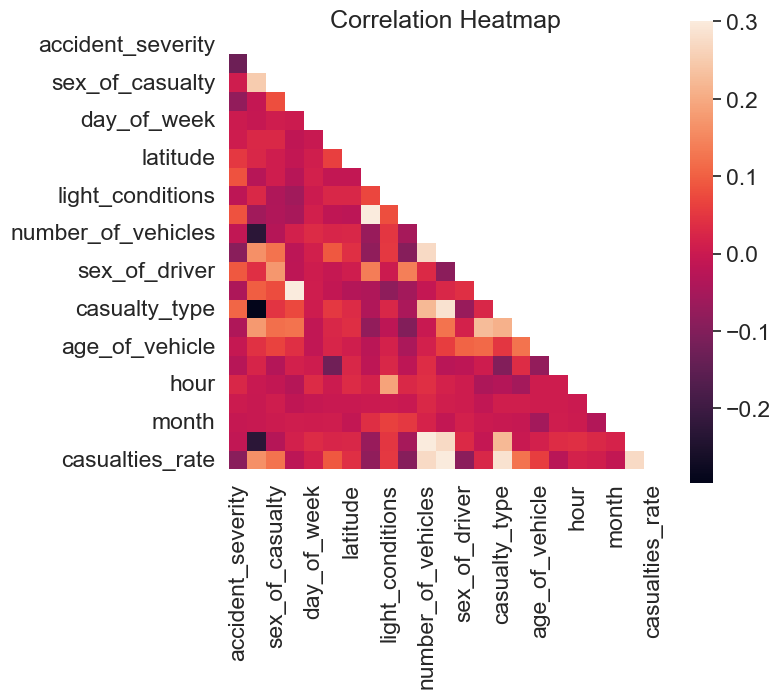

In [23]:
# To examine the correlation matrix of continuous variables
df_num = df.select_dtypes(include=[np.number])
constant_cols = df_num.columns[df_num.nunique() <= 1]
df_num.drop(columns=constant_cols, inplace=True)
corr = df_num.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(7, 6))
sns.heatmap(corr, mask=mask, vmax=.3, square=True)
plt.title("Correlation Heatmap")
plt.show()

From the processed dataset, we could figure out that most features are independent. highly correlated variables are features related to casualty and vehicle conditions as well as road surface and weather.

### 4.1.4 Exploratory Data Analysis

**4.1.4.1 Descriptive Statistics for Numeric Columns**

In [24]:
df.describe()

,accident_severity,casualty_class,sex_of_casualty,age_of_casualty,day_of_week,accident_year,longitude,latitude,weather_conditions,light_conditions,...,age_of_driver,casualty_type,engine_capacity_cc,age_of_vehicle,Job density,hour,day,month,vehicles_rate,casualties_rate
count,48149.000000,48149.000000,46195.000000,46085.000000,48149.000000,48149.0,48149.000000,48149.000000,48149.000000,48149.000000,...,36769.000000,48149.000000,36198.000000,37749.000000,48149.000000,48149.000000,48149.000000,48149.000000,48149.000000,48149.000000
mean,2.842489,1.347089,1.304189,36.128024,4.158799,2023.0,-0.115992,51.509417,2.089721,2.042555,...,38.931110,3.251822,1679.768274,7.383931,1.080324,13.943093,15.839228,6.572577,0.000021,0.000021
std,0.376951,0.654028,0.460068,15.296899,1.944822,0.0,0.143818,0.070482,2.488723,1.551127,...,14.172574,1.396194,1427.435882,5.320985,1.095692,5.542206,8.692735,3.355404,0.000010,0.000014
min,1.000000,1.000000,1.000000,0.000000,1.000000,2023.0,-0.509865,51.289491,1.000000,1.000000,...,2.000000,1.000000,25.000000,0.000000,0.430000,0.000000,1.000000,1.000000,0.000010,0.000015
25%,3.000000,1.000000,1.000000,25.000000,3.000000,2023.0,-0.199254,51.464168,1.000000,1.000000,...,28.000000,2.000000,1124.000000,3.000000,0.590000,10.000000,8.000000,4.000000,0.000020,0.000015
50%,3.000000,1.000000,1.000000,33.000000,4.000000,2023.0,-0.112267,51.514295,1.000000,1.000000,...,36.000000,3.000000,1580.000000,6.000000,0.630000,15.000000,16.000000,7.000000,0.000020,0.000015
75%,3.000000,1.000000,2.000000,45.000000,6.000000,2023.0,-0.031592,51.558299,1.000000,4.000000,...,48.000000,4.000000,1995.000000,11.000000,1.030000,18.000000,23.000000,9.000000,0.000020,0.000015
max,3.000000,3.000000,2.000000,99.000000,7.000000,2023.0,0.294829,51.691229,9.000000,7.000000,...,97.000000,8.000000,29980.000000,68.000000,5.330000,23.000000,31.000000,12.000000,0.000167,0.000116


In [25]:
df = df[df["age_of_vehicle"] < 35]  # most age_of_vehicle>35 is null

**4.1.4.2 Frequency Count for Categroical Columns**

In [26]:
df.describe(include=[object])

,date,time,Code,Area,accident_severity_category,casualty_class_category,sex_of_casualty_category,sex_of_driver_category,casualty_type_category,day_of_week_category,weather_conditions_category,road_surface_conditions_category
count,37727,37727,37727,37727,37727,37727,36127,37727,37727,37727,37727,37727
unique,365,1373,32,32,3,3,2,3,8,7,9,6
top,26/05/2023,17:00,E09000008,Croydon,slight,Driver/Rider,Male,Male,Car,Friday,Fine no high winds,Dry
freq,217,374,2017,2017,32278,27855,24971,22271,15761,6154,28483,27484


**4.1.4.3 Distribution of Data**

Counts of slight cases =  32278
Counts of serious cases =  5243
Counts of fatal cases =  206


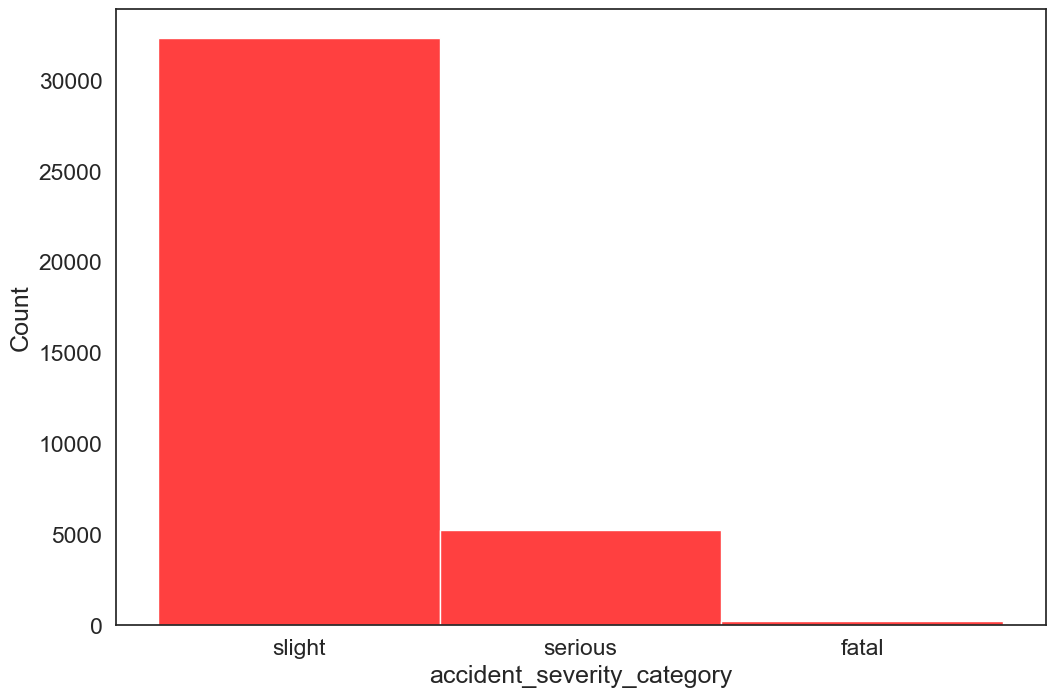

In [27]:
fatal   = len(df[df['accident_severity_category'] == 'fatal'])
serious = len(df[df['accident_severity_category'] == 'serious'])
slight  = len(df[df['accident_severity_category'] == 'slight'])

sns.histplot(data=df, x="accident_severity_category", color = 'Red')

print('Counts of slight cases = ', slight)
print('Counts of serious cases = ', serious)
print('Counts of fatal cases = ', fatal)

The frequency charts demonstrate that **slight severity** occur most frequently, showing a large number of slight cases compared to significantly fewer serious and very few fatal ones.

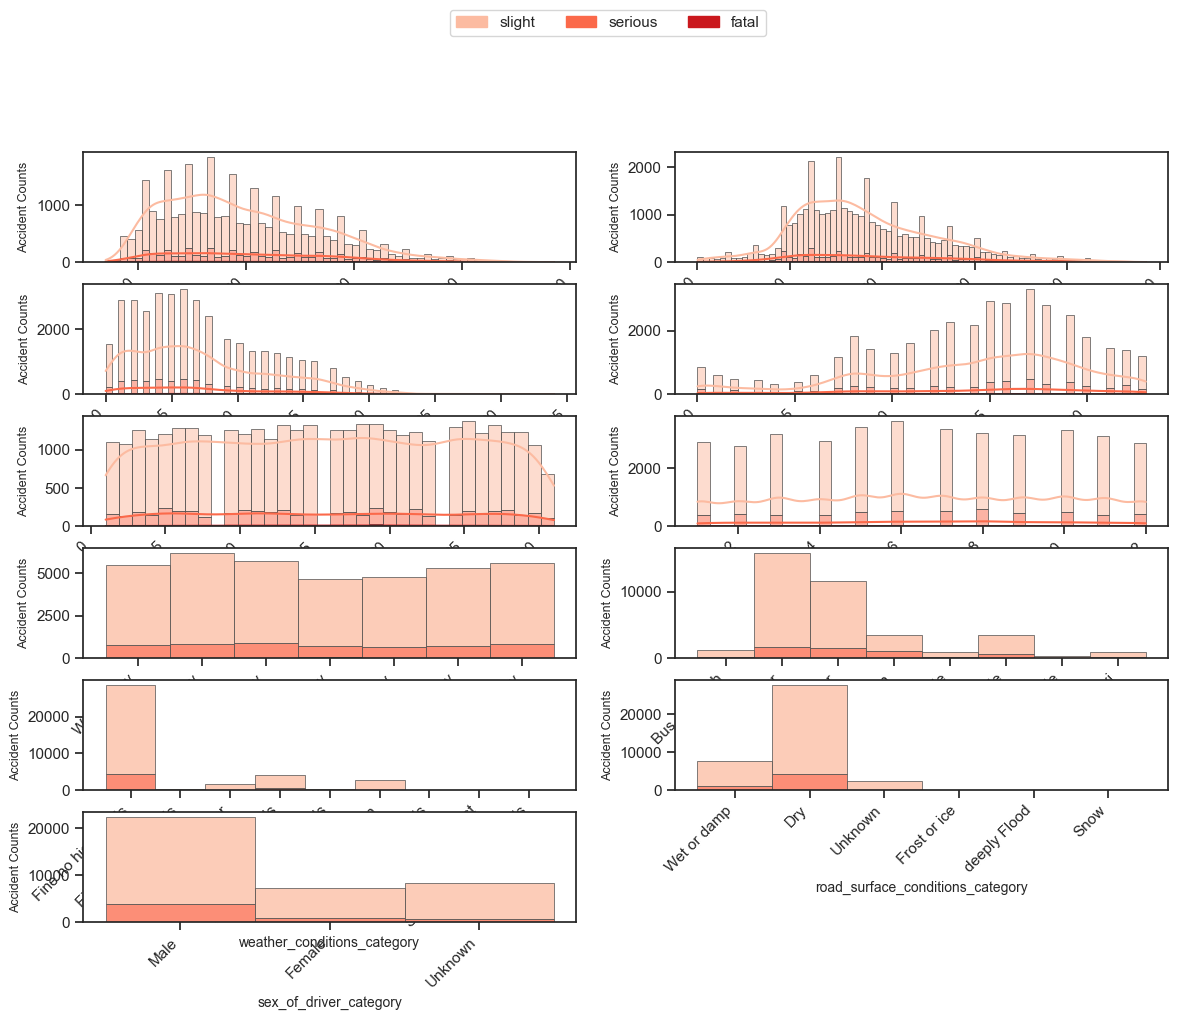

In [30]:
sns.set_theme(style="ticks")
categorical_vars = {
    "casualty_type_category",
    "day_of_week_category",
    "weather_conditions_category",
    "road_surface_conditions_category",
    "sex_of_driver_category"
}

severity_order = ["slight", "serious", "fatal"]
my_palette = sns.color_palette("Reds", n_colors=3)
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(6, 2, figure=fig)

vars_to_plot = [
    "age_of_driver",        
    "age_of_casualty", 
    "age_of_vehicle",
    "hour",
    "day",
    "month",
    "day_of_week_category",
    "casualty_type_category",
    "weather_conditions_category",
    "road_surface_conditions_category",
    "sex_of_driver_category"
]

for idx, var in enumerate(vars_to_plot):
    ax = fig.add_subplot(gs[idx])
    if var in categorical_vars:
        df_cat = df.copy()
        df_cat[var] = df_cat[var].astype(str)
        
        sns.histplot(
            data=df_cat,
            x=var,
            hue="accident_severity_category",
            hue_order=severity_order,       # <--- use custom order
            multiple="stack",
            discrete=True,
            palette=my_palette,
            edgecolor=".3",
            linewidth=0.5,
            ax=ax,
            legend=False
        )
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel("Accident Counts", fontsize=9)
    else:
        data_to_plot = df.dropna(subset=[var])
        sns.histplot(
            data=data_to_plot,
            x=var,
            hue="accident_severity_category",
            hue_order=severity_order,
            multiple="stack",
            palette=my_palette,
            kde=True,
            edgecolor=".3",
            linewidth=0.5,
            ax=ax,
            legend=False
        )
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel("Accident Counts", fontsize=9)
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

patches = [mpatches.Patch(color=my_palette[i], label=severity_order[i]) for i in range(3)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3)

plt.tight_layout()
plt.show()

The analysis of time shows a noticeable peak occurring around **17:00**, which seems to indicate that late afternoon or early evening, particularly towards the rush hour, is a more dangerous period for traffic accidents.  Specifically, **Friday** stands out, as it has recorded the most incidents, with about 6,154 cases, making it the day with the highest number of accidents during the week.  The data suggests that most of the individuals involved in accidents are in the age group of **20 to 35** years.  Within this broad age group, it is noted that the highest number of casualties happen between the ages of **25** and **30**.  This may imply that the majority of traffic incidents occur with individuals in their active and potentially more prone to risk-taking years. Furthermore, a considerable portion of accidents seems to be linked to **car occupants**, and many of these accidents occur under typical, not very severe, conditions, which might not seem too risky initially.  **Male** drivers seem to be involved in these accidents at a higher frequency, which suggests that gender might play a role in the occurrence of traffic incidents.

After carried out the descriptive statistics. We plotted the distribution of some key numeric columns and the count of accident cases in each borough to visualize the distribution of data more thoroughly.

**4.1.4.4 spatial distribution of accident severity**

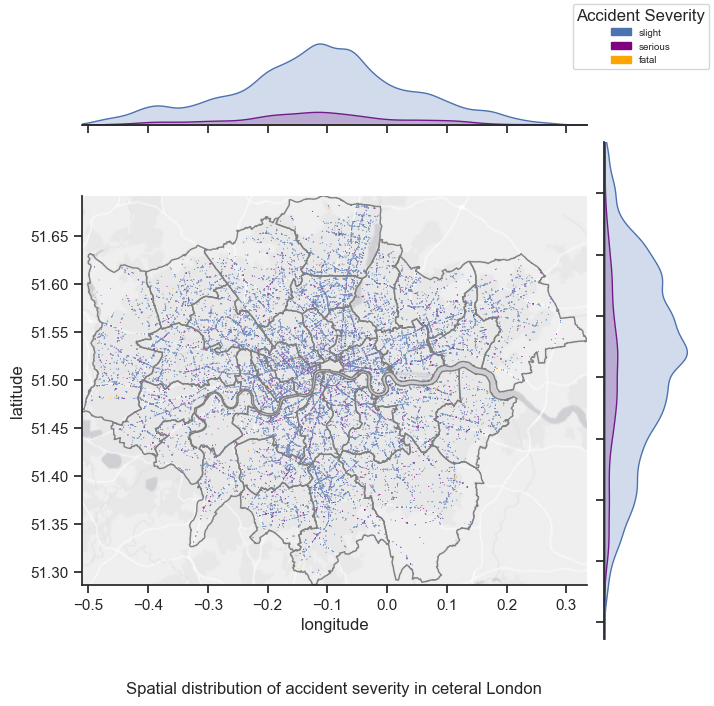

In [31]:
if df.crs is None:
    df.set_crs(epsg=4326, inplace=True)

boroughs = ward.to_crs(epsg=4326)
g = sns.jointplot(
    x='longitude',
    y='latitude',
    hue="accident_severity_category",
    palette=['b', 'purple', 'orange'],
    data=df,
    s=0.5,
    height=7
)

contextily.add_basemap(
    g.ax_joint,
    crs="EPSG:4326",
    source=contextily.providers.Esri.WorldGrayCanvas,
    attribution=False
)
boroughs.boundary.plot(ax=g.ax_joint, edgecolor='gray', linewidth=1)
g.ax_joint.legend_.remove()
handles = [
    mpatches.Patch(color='b', label='slight'),
    mpatches.Patch(color='purple', label='serious'),
    mpatches.Patch(color='orange', label='fatal')
]
g.fig.legend(
    handles=handles,
    loc='upper right',
    fontsize=7,
    title="Accident Severity"
)
plt.subplots_adjust(top=0.95)
minx, miny, maxx, maxy = boroughs.total_bounds
g.ax_joint.set_xlim(minx, maxx)
g.ax_joint.set_ylim(miny, maxy)
g.ax_joint.set_title('Spatial distribution of accident severity in ceteral London', loc='center', y=-0.3)
plt.show()

As illustrated in Figure, the majority of accidents are concentrated in inner London, particularly in locations such as Westminster, the City of London, and Islington. Conversely, fewer accidents occur in the suburban regions. This implies that the density of people and vehicles in bustling urban centres is a significant factor leading to a higher number of accidents than that in more tranquil suburban areas.

## 5. Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodologies]*

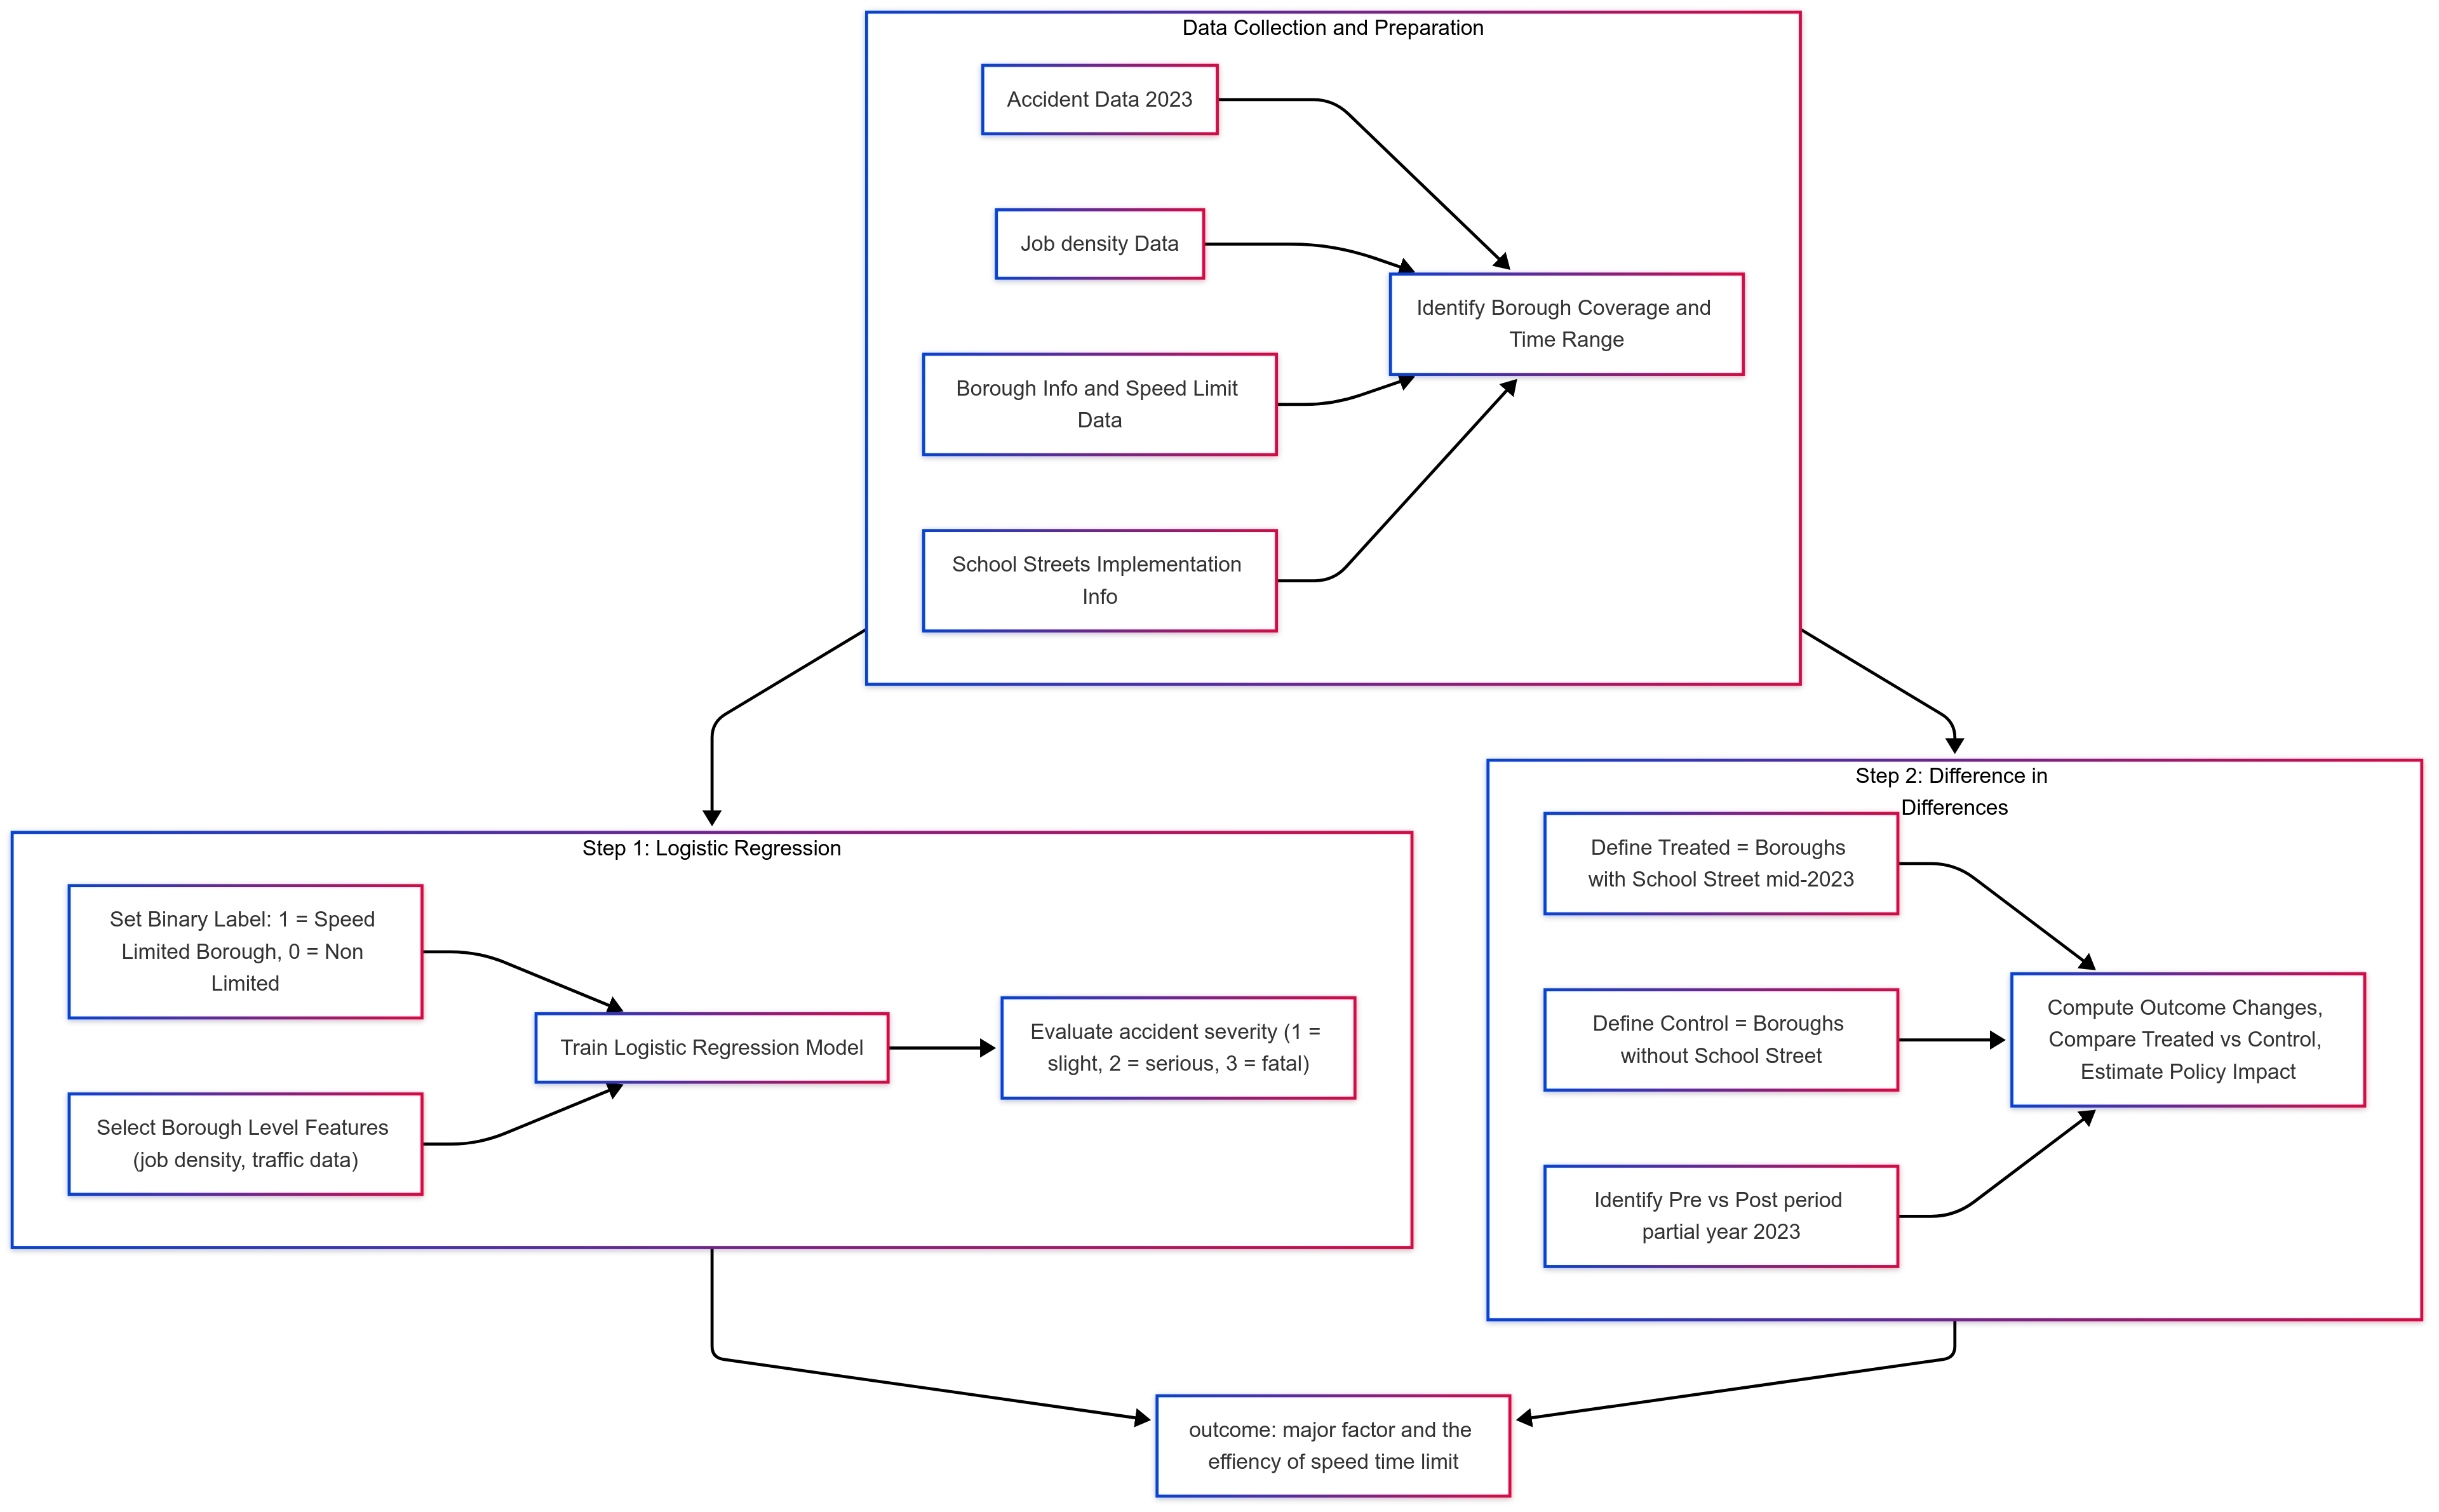

After we carrying out exploratory analysis on the dataset, we could obviously find out thta the datasets'classes of traffic accidents are non-uniformly distributed over the data space, namely, highly skewed distribution. According to [Sahare and Gupta](#Sahare-and-Gupta) ([2012](#Sahare-and-Gupta)), application of basic algorithms of learning classifier for MCC on imbalanced dataset will be a great challenge. But we could still attempt to seek for some highlights of strength and limitations and gain some insights from the performance of each model present some results.
Logistic regression to preidct the traffic severity in classification was implemented and compared in this project.

## 5.1 Logistic Regression

### 5.1.1 Model Description

*[Note: a flow chart that describes the procedure]*

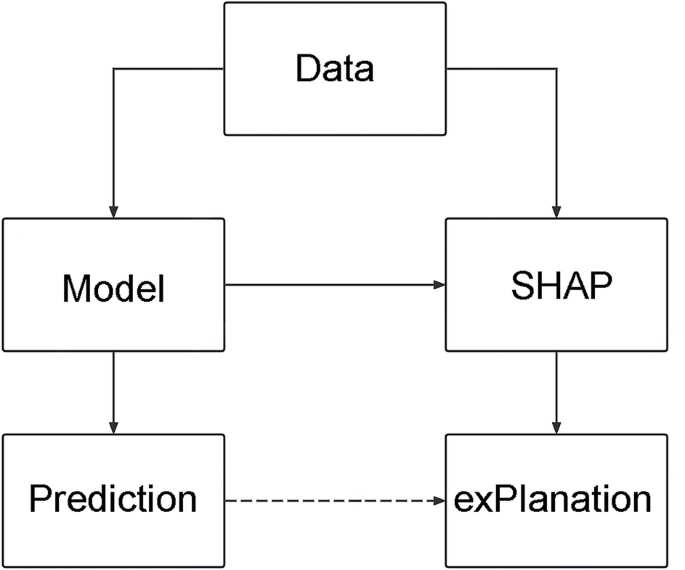

### 5.1.1 build model and present outcome

I will combine serious and fatal together not only because the minimal number of fatal category but the vague difference between them.

In [32]:
df['severity_binary'] = df['accident_severity_category'].replace({
    'slight': 'slight',
    'serious': 'severe',
    'fatal': 'severe'
})
df['severity_code'] = df['severity_binary'].map({'slight': 0, 'severe': 1})
label_order = ['slight', 'severe']

In [33]:
df['severity_binary'].head()

0    slight
1    slight
2    slight
5    slight
6    slight
Name: severity_binary, dtype: object

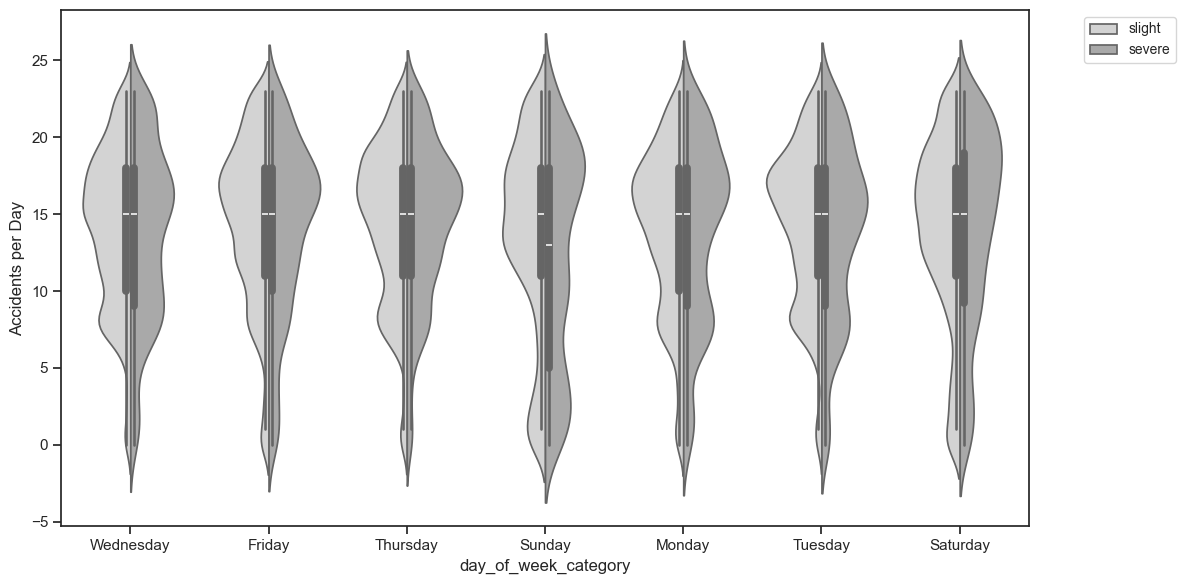

In [34]:
# Violin plot of accidents per day by severity
df_filtered = df[df['severity_binary'].isin(['slight', 'severe'])]
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_filtered, x='day_of_week_category', y='hour', 
               hue='severity_binary', split=True, 
               palette={'slight': 'lightgray', 'severe': 'darkgray'}, ax=ax)
ax.set_ylabel('Accidents per Day')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


Such violin chart demostrates the distripution of daily slight and severe accidents in a week. It's easy to find that the distribution of accident times no matter slight or severe throughout all weeks shows a similar bimodal pattern to some extend, mainly concentrated during the morning and evening rush hours but the evening has more frequent severe accidents which means there is some sort of diversity between accident severity and time.

In [35]:
#choose the specific variables that I want to explore
numeric_features = [
    'age_of_driver', 'age_of_vehicle',
    'hour', 'Job density', 'number_of_vehicles',
    'vehicles_rate', 'casualties_rate'
]

categorical_features = [
    'weather_conditions_category',
    'road_surface_conditions_category',
    'day_of_week_category',
    'casualty_type_category',
    'sex_of_driver_category'
]

# remove unknown lables
for col in categorical_features:
    df = df[~df[col].str.contains("Unknown", na=False)]


X = df[numeric_features + categorical_features]
y = df['severity_code']

#preprocess the datasets
numeric_tf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])

categorical_tf = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh',  OneHotEncoder(handle_unknown='ignore'))
])

pre = ColumnTransformer([
    ('num', numeric_tf, numeric_features),
    ('cat', categorical_tf, categorical_features)
])

#classify the model
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

clf = Pipeline([
    ('pre', pre),
    ('model', logreg)
])

# split train dataset and test dataset
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

clf.fit(X_tr, y_tr)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Outcome is as below:

              precision    recall  f1-score   support

      slight      0.902     0.658     0.761      6931
      severe      0.277     0.647     0.388      1408

    accuracy                          0.656      8339
   macro avg      0.590     0.652     0.574      8339
weighted avg      0.796     0.656     0.698      8339



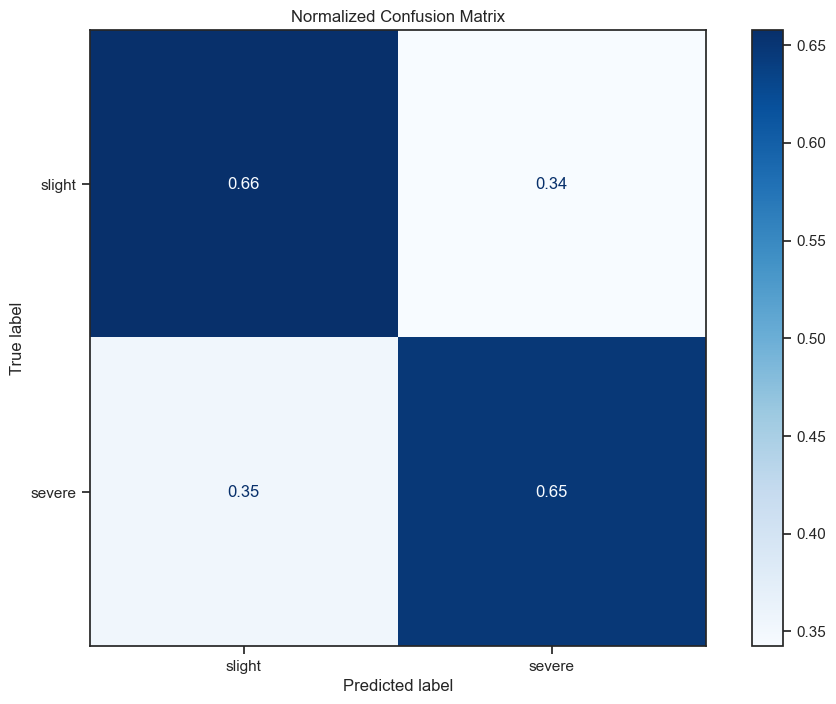

Binary ROC-AUC = 0.701


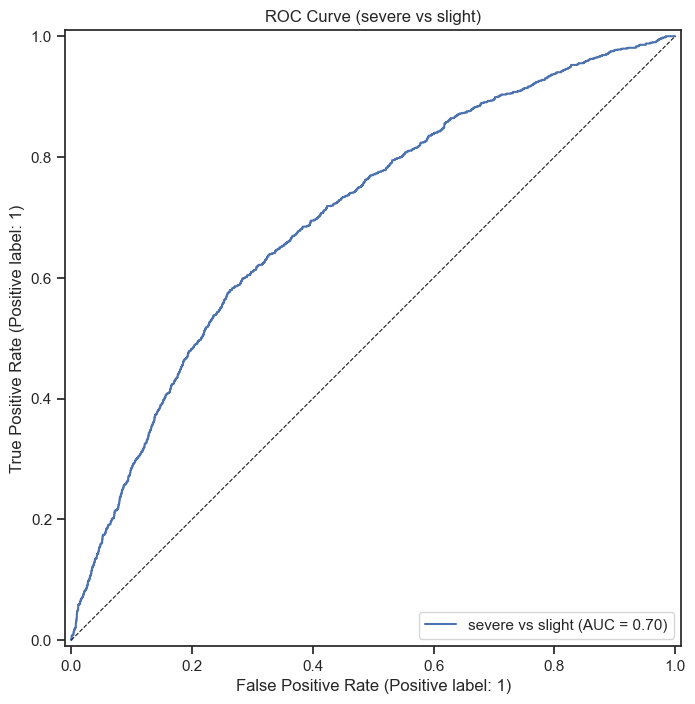

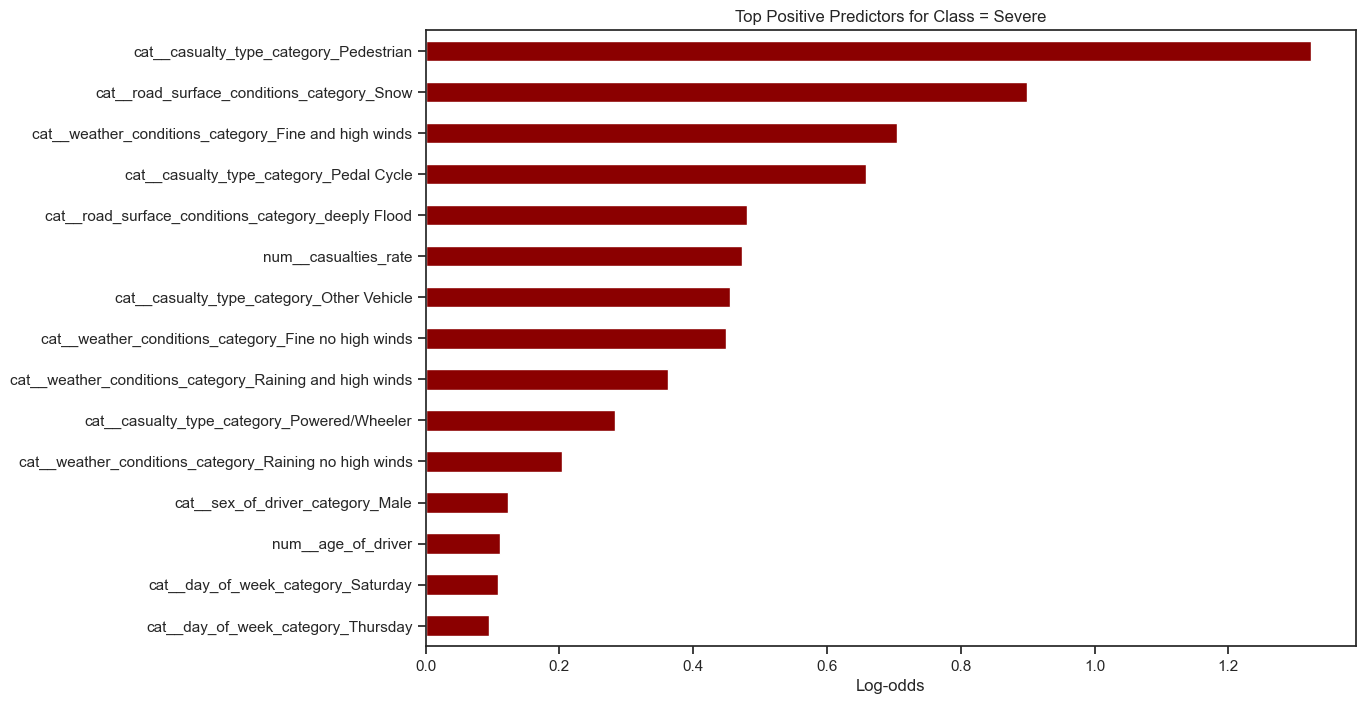

In [36]:
# get assessment report
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred, target_names=label_order, digits=3))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=label_order,
    cmap='Blues',
    normalize='true'
)
plt.title("Normalized Confusion Matrix"); plt.show()

# get ROC-AUC line
y_proba = clf.predict_proba(X_te)
auc = roc_auc_score(y_te, y_proba[:, 1])
print(f"Binary ROC-AUC = {auc:.3f}")

RocCurveDisplay.from_predictions(
    y_te, y_proba[:, 1],
    name='severe vs slight'
)
plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
plt.title("ROC Curve (severe vs slight)"); plt.show()

# explian the coefficients
coefs = clf.named_steps['model'].coef_[0]
feat_names = clf.named_steps['pre'].get_feature_names_out()
coef_series = pd.Series(coefs, index=feat_names).sort_values()

# the top 15 crucial variables visualization
coef_series.tail(15).plot(kind='barh', color='darkred')
plt.title('Top Positive Predictors for Class = Severe')
plt.xlabel('Log-odds'); plt.show()

Accuracy of logistic regression is **65.6%**, AUC is **0.70**. Recall for severe cases is quite high (0.647).
Pedestrian casuals, snow and adverse weather are significant predictors of severe accidents. Thus, the model is able to explain environmental and vulnerability risk factors.

### 5.1.2 Shape analysis

In [37]:
# Get the preprocessor and the model
preprocessor = clf.named_steps['pre']
model = clf.named_steps['model']

# Use transform to get the variables after processing
X_te_transformed = preprocessor.transform(X_te)
feature_names = preprocessor.get_feature_names_out()

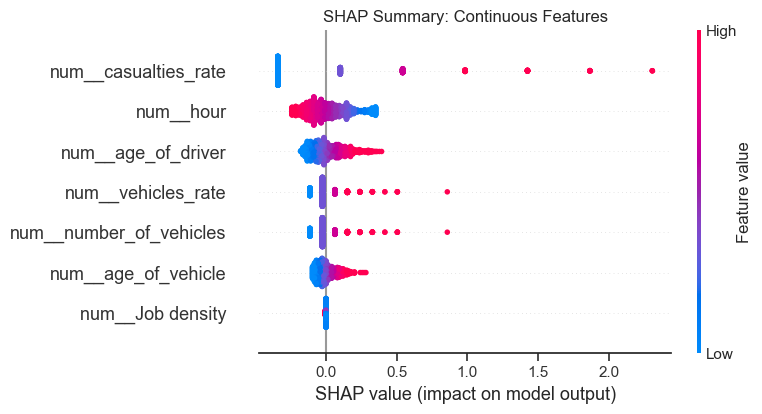

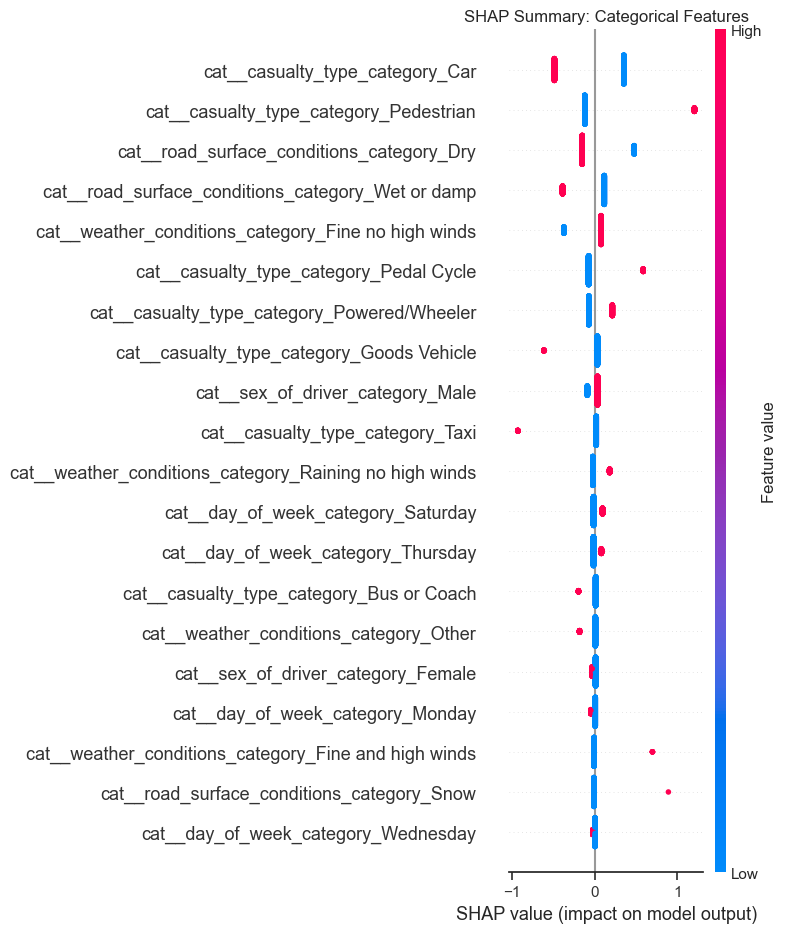

In [38]:
# build explainer
explainer = shap.LinearExplainer(model, X_te_transformed, feature_perturbation="interventional")

# calculate all SHAP values
shap_values_all = explainer.shap_values(X_te_transformed[:1000])
all_names = list(feature_names)

# split continuous and categories variables
num_idx = []
for i, name in enumerate(all_names):
    if any(name.startswith(f"num__{col}") for col in numeric_features):
        num_idx.append(i)
cat_idx = [i for i in range(len(all_names)) if i not in num_idx]

# continuous variables' SHAP summary plot
shap.summary_plot(
    np.array(shap_values_all)[:, num_idx],        # shap values for numeric
    X_te_transformed[:1000, num_idx],             # feature matrix
    feature_names=[all_names[i] for i in num_idx],
    show=False
)
plt.title("SHAP Summary: Continuous Features")
plt.tight_layout()
plt.show()

# c SHAP summary plot
shap.summary_plot(
    np.array(shap_values_all)[:, cat_idx],        # shap values for categorical
    X_te_transformed[:1000, cat_idx],             # feature matrix
    feature_names=[all_names[i] for i in cat_idx],
    show=False
)
plt.title("SHAP Summary: Categorical Features")
plt.tight_layout()
plt.show()

From the Shape output, It's not diffcult to figure out that the model's top drivers of severe accidents are casualty type, injury rate and road conditions. Higher values of casualty rate and one-hot flags for **pedestrian and pedal-cycle casualties** push predictions strongly towards severe. Adverse **surfaces wet or damp roads** increase risk, while dry surfaces and fine weather pull predictions towards slight. Temporal influence is small: later hours (e.g., night) slightly increase severity. **Higher number of vehicles and vehicle** age increase severity, while car/coach and bus casualty flags have little or no impact on severity. Overall, the plot shows the model correctly learns that vulnerable road users (pedestrians, cyclists), high injury density and poor surface conditions are the top predictors of severe accidents.

## 5.2 Difference in Difference

## Policy Context and Research Design

This study evaluates the impact of 20mph speed limit policies on traffic accident severity using a quasi-experimental approach. While TfL has been implementing 20mph zones across London boroughs, **detailed borough-level policy implementation data with precise timing is not readily available** in public datasets.

**Known Policy Background (2023):**
- Inner London boroughs (Camden, Islington, Hackney, Haringey, Tower Hamlets) had extensive 20mph coverage before September 2023
- TfL announced additional 20mph implementations in September 2023, particularly in South London
- However, specific borough-level implementation schedules are not comprehensively documented

**Research Design Approach:**
Given these data limitations, we construct a quasi-experimental framework using borough-level variation in 20mph policy timing. Our treatment group selection represents areas that likely experienced policy changes around September 2023, allowing us to:

1. **Demonstrate DID methodology** for transportation policy evaluation
2. **Test analytical frameworks** applicable to policy impact assessment
3. **Explore accident severity patterns** across different London areas

**Data Limitation Acknowledgment:** The precise identification of policy treatment timing remains a challenge in transportation policy research due to limited granular policy implementation data.

**Reference**: TfL research shows 20mph speed limits save lives on London's roads ([TfL Press Release](https://tfl.gov.uk/info-for/media/press-releases/2025/may/powerful-new-long-term-tfl-research-shows-20mph-speed-limits-save-lives-on-london-s-roads))

## Treatment and Control Group Definition

Based on TfL's London Speed Limit Map analysis and 20mph zone coverage patterns, we define our treatment and control groups as follows:

**Treatment Group (Enhanced 20mph Enforcement Areas from September 2023):**

- Barking and Dagenham
- Havering  
- Newham
- Redbridge
- Hounslow
- Hillingdon
- Harrow
- Sutton
- Enfield

**Note**: Treatment group includes 9 outer London boroughs with limited 20mph coverage prior to September 2023, based on data availability in our traffic accident dataset.

**Control Group:** All remaining London boroughs after propensity score matching

### Rationale for Group Selection:

The treatment group selection is based on TfL's speed limit mapping data, which shows these boroughs had **relatively lower 20mph zone coverage** prior to September 2023, making them candidates for enhanced 20mph enforcement policies. This quasi-experimental design allows us to:

1. **Leverage natural variation**: Compare areas with newly enhanced 20mph enforcement against established 20mph zones
2. **Geographic representation**: Comprehensive coverage of outer London boroughs across all directions (East, West, South, North) with consistently low 20mph zone density
3. **Policy relevance**: Align with TfL's strategy of expanding 20mph zones to areas with previously limited coverage
4. **Methodological rigor**: Ensure adequate pre-post policy periods for robust DID estimation

**Data Source**: TfL London Digital Speed Limit Map (November 2023) showing 20mph zone distribution across London boroughs.

$$
\mathrm{severity}_{b,t}
\;=\;
\alpha\cdot \mathrm{Open}_{b,t}
\;+\;
\gamma_b
\;+\;
\delta_t
\;+\;
\boldsymbol{\beta}'\,X_{b,t}
\;+\;
\varepsilon_{b,t}
$$

$$
 \gamma_b：Borough fixed effect;
 \delta_t：Months fixed effect;  
\boldsymbol{\beta}'\,X_{b,t}： any other influential factors
$$

### 5.2.1 Panel Regression Exercise
Before setting up a difference in differences design, we run a panel regression in which unemployment is the dependent variable and minimum wage is the independent variable. 

In [95]:
match_covs = [
    'Job density',
    'number_of_vehicles',
    'vehicles_rate',
    'casualties_rate',
    'age_of_vehicle',
    'age_of_driver',
    'engine_capacity_cc'
]

weather_dummies = pd.get_dummies(df['weather_conditions_category'], prefix='weather')
road_dummies    = pd.get_dummies(df['road_surface_conditions_category'],  prefix='road')
light_dummies   = pd.get_dummies(df['light_conditions'],                prefix='light')
cov_means = {c: 'mean' for c in match_covs}
cov_means.update({col: 'mean' for col in weather_dummies.columns})
cov_means.update({col: 'mean' for col in road_dummies.columns})
cov_means.update({col: 'mean' for col in light_dummies.columns})
cov_means['treat'] = 'first'  

In [103]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['Area','date','severity_code']).copy() 
treat_boros = [
 "Barking and Dagenham",
 "Havering",
 "Newham",
 "Redbridge",
 "Hounslow",
 "Hillingdon",
 "Harrow",
 "Sutton",
 "Enfield"
]
policy_day = pd.to_datetime("2023-09-01")


df_pre = df[df['date'] < policy_day].copy()
df_pre['month'] = df_pre['date'].dt.to_period('M')

weather_dummies = pd.get_dummies(
    df_pre['weather_conditions_category'], prefix='weather')
road_dummies    = pd.get_dummies(
    df_pre['road_surface_conditions_category'], prefix='road')
light_dummies   = pd.get_dummies(
    df_pre['light_conditions'], prefix='light')

df_cov = pd.concat(
    [df_pre, weather_dummies, road_dummies, light_dummies],
    axis=1
)
agg_map = {
    **{c:'mean' for c in match_covs},
    **{col:'mean' for col in weather_dummies.columns},
    **{col:'mean' for col in road_dummies.columns},
    **{col:'mean' for col in light_dummies.columns},
}
df_b = (
    df_cov
    .groupby(['Area','month'], as_index=False)
    .agg(agg_map)
)

#  treat
df_b['treat'] = df_b['Area'].isin(treat_boros).astype(int)

#  propensity score
ps_model = LogisticRegression(max_iter=1000)
X_ps = df_b[match_covs]
y_ps = df_b['treat']
ps_model.fit(X_ps, y_ps)
df_b['pscore'] = ps_model.predict_proba(X_ps)[:,1]

treated = df_b[df_b['treat']==1]
control = df_b[df_b['treat']==0]
nn = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])
dist, idx = nn.kneighbors(treated[['pscore']])
caliper = 0.02
mask = dist.flatten() <= caliper
matched_treated = treated[mask].copy()
matched_control = control.iloc[idx.flatten()[mask]].copy()

control_boros = list(set(matched_control['Area'].tolist()) - set(treat_boros))

# —— 4. 构造匹配后全时段样本 df_matched —— 
selected_boros = treat_boros + control_boros
df_matched = df[df['Area'].isin(selected_boros)].copy()
df_matched['treat'] = df_matched['Area'].isin(treat_boros).astype(int)
df_matched['post']  = (df_matched['date'] >= policy_day).astype(int)
df_matched['did']   = df_matched['treat'] * df_matched['post']

In [97]:
# 检查匹配前后协变量平衡
print("Treatment areas:", treat_boros)
print("Control areas:", control_boros)

Treatment areas: ['Barking and Dagenham', 'Hounslow', 'Hillingdon', 'Sutton', 'Islington', 'Newham']
Control areas: ['Croydon', 'Merton', 'Kensington and Chelsea', 'Hackney', 'Ealing', 'Lambeth', 'Bexley', 'Southwark', 'Camden', 'Haringey', 'Waltham Forest', 'Barnet', 'Greenwich', 'Lewisham', 'Hammersmith and Fulham', 'Havering', 'Westminster', 'Brent', 'Kingston upon Thames', 'Redbridge', 'Harrow', 'Enfield', 'Tower Hamlets']


Treatment group boroughs: 9
Control group boroughs: 18


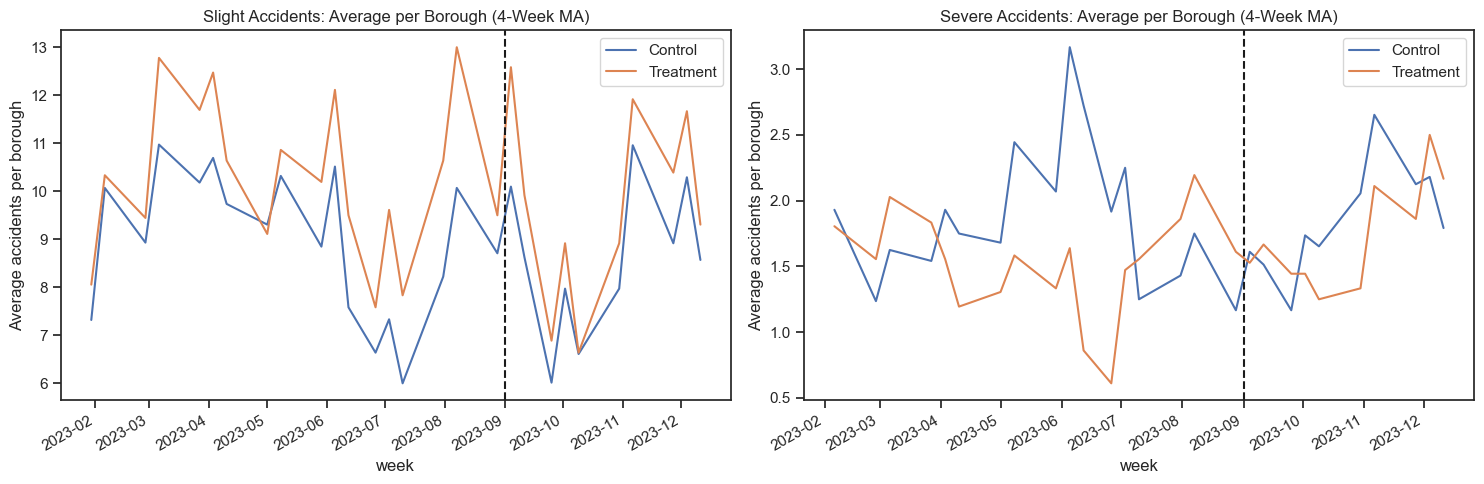


=== DID Analysis with Normalized Data ===
slight: DID coeff = -0.1972, p-value = 0.3915
severe: DID coeff = 0.2263, p-value = 0.5301

Difference in DID effects: 0.2263


In [ ]:
treat_count = df_matched[df_matched['treat']==1]['Area'].nunique()
control_count = df_matched[df_matched['treat']==0]['Area'].nunique()

print(f"Treatment group boroughs: {treat_count}")
print(f"Control group boroughs: {control_count}")

# 重新绘制标准化的平行趋势图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, severity in enumerate(['slight', 'severe']):
    df_sev = df_matched[df_matched['severity_binary'] == severity]
    
    # 计算每周每个treat group的总事故数
    weekly_sev = df_sev.groupby(['week','treat']).size().unstack('treat').fillna(0)
    
    # 标准化：除以各自group的borough数量
    weekly_sev[0] = weekly_sev[0] / control_count  # Control group
    weekly_sev[1] = weekly_sev[1] / treat_count    # Treatment group
    weekly_sev_ma = weekly_sev.rolling(4).mean()
    
    weekly_sev_ma.plot(ax=axes[i])
    axes[i].axvline(policy_day, linestyle='--', color='k')
    axes[i].set_title(f"{severity.title()} Accidents: Average per Borough (4-Week MA)")
    axes[i].set_ylabel("Average accidents per borough")
    axes[i].legend(["Control", "Treatment"])

plt.tight_layout()
plt.show()

print("\n=== DID Analysis with Normalized Data ===")
for severity in ['slight', 'severe']:
    df_sev = df_matched[df_matched['severity_binary'] == severity].copy()
    daily_rate = (df_sev.groupby(['Area', 'date', 'treat', 'post', 'did'])
                  .size().reset_index(name='daily_accidents'))
    
    # DID回归
    formula = "daily_accidents ~ did + treat + post"
    mod = smf.ols(formula, data=daily_rate).fit()
    
    print(f"{severity}: DID coeff = {mod.params['did']:.4f}, p-value = {mod.pvalues['did']:.4f}")

print(f"\nDifference in DID effects: {mod.params['did']:.4f}")  # This will show the last one, but you get the idea


<Axes: xlabel='week'>

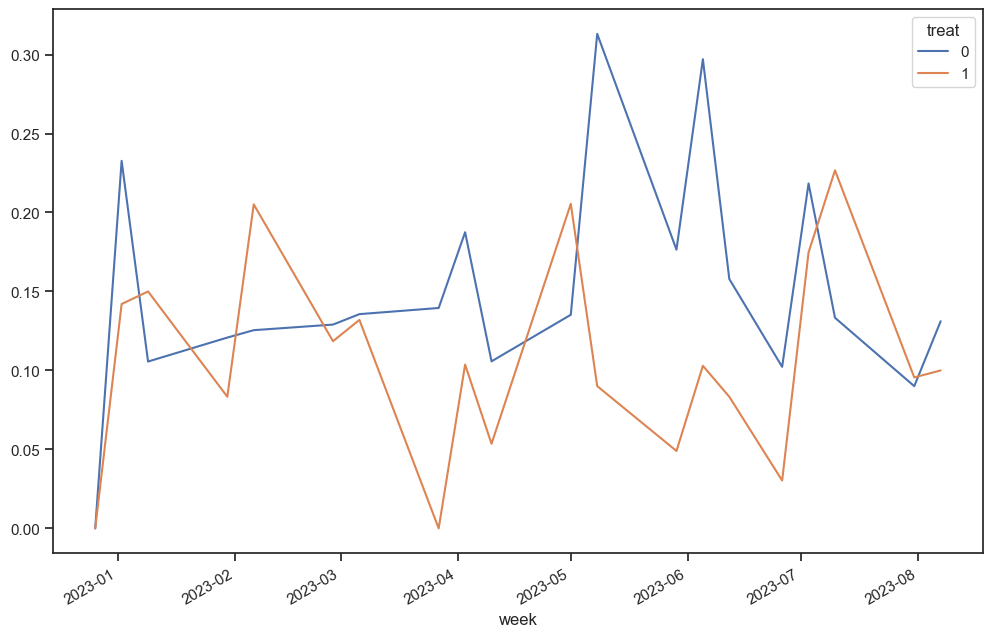

In [107]:
df_pre = df_matched[df_matched['date'] < policy_day]
df_pre['week'] = df_pre['date'].dt.to_period('W').dt.start_time
weekly_pre = df_pre.groupby(['week','treat'])['severity_code'].mean().unstack('treat')
weekly_pre.plot()

From the output, It's not hard to figure out that it's not parallel from 2023-01 to 2023-06 which sometimes caused contrary tendency. From that case, the key is compressing timeframe and choosing parallel one before policy time what would be 2023-06 to 2023-09.

In [114]:
# Final DID Analysis with Optimized Time Window
print("=== FINAL DID ANALYSIS (June-December 2023) ===")

# Use June 1st as analysis starting point
analysis_start = pd.to_datetime("2023-06-01")
df_final = df_matched[df_matched['date'] >= analysis_start].copy()

print(f"Analysis sample: {len(df_final)} observations")
print(f"Time range: {df_final['date'].min()} to {df_final['date'].max()}")

# Redefine post-policy indicator
df_final['post'] = (df_final['date'] >= policy_day).astype(int)
df_final['did'] = df_final['treat'] * df_final['post']

# Final DID regression with time trend controls
final_formula = """severity_code ~ did + treat + post + month + month_sq + 
                   hour + number_of_vehicles + casualties_rate"""

mod_final = smf.ols(final_formula, data=df_final).fit()

print(f"\n=== MAIN DID RESULTS ===")
print(f"DID coefficient: {mod_final.params['did']:.4f}")
print(f"Standard error: {mod_final.bse['did']:.4f}")
print(f"p-value: {mod_final.pvalues['did']:.4f}")
print(f"95% confidence interval: [{mod_final.conf_int().loc['did', 0]:.4f}, {mod_final.conf_int().loc['did', 1]:.4f}]")

# Statistical significance assessment
if mod_final.pvalues['did'] < 0.05:
    print("Result: Statistically significant (p < 0.05)")
elif mod_final.pvalues['did'] < 0.10:
    print("Result: Marginally significant (p < 0.10)")
else:
    print("Result: Not significant (p ≥ 0.10)")

# Effect size interpretation
effect_size = mod_final.params['did']
baseline_severity = df_final[df_final['treat']==1]['severity_code'].mean()
relative_effect = (effect_size / baseline_severity) * 100

print(f"\n=== EFFECT SIZE INTERPRETATION ===")
print(f"Baseline severity score: {baseline_severity:.3f}")
print(f"Absolute effect: {effect_size:.4f} points")
print(f"Relative effect: {relative_effect:.1f}%")

# Robustness checks with different time windows
print(f"\n=== ROBUSTNESS CHECKS ===")
windows = [
    ("2023-07-01", "July start"),
    ("2023-05-01", "May start"),
    ("2023-04-01", "April start")
]

for start_date, label in windows:
    df_robust = df_matched[df_matched['date'] >= start_date].copy()
    df_robust['post'] = (df_robust['date'] >= policy_day).astype(int)
    df_robust['did'] = df_robust['treat'] * df_robust['post']
    
    try:
        mod_robust = smf.ols(final_formula, data=df_robust).fit()
        did_coef = mod_robust.params['did']
        did_pval = mod_robust.pvalues['did']
        print(f"{label}: DID={did_coef:.4f}, p={did_pval:.3f}")
    except:
        print(f"{label}: Regression failed")

print(f"\n=== CONCLUSIONS ===")
if mod_final.pvalues['did'] < 0.10:
    direction = "increased" if effect_size > 0 else "decreased"
    print(f"20mph policy significantly {direction} accident severity")
else:
    print("20mph policy had no significant effect on accident severity (null effect)")


=== FINAL DID ANALYSIS (June-December 2023) ===
Analysis sample: 5332 observations
Time range: 2023-06-01 00:00:00 to 2023-12-12 00:00:00

=== MAIN DID RESULTS ===
DID coefficient: 0.0388
Standard error: 0.0215
p-value: 0.0711
95% confidence interval: [-0.0033, 0.0809]
Result: Marginally significant (p < 0.10)

=== EFFECT SIZE INTERPRETATION ===
Baseline severity score: 0.143
Absolute effect: 0.0388 points
Relative effect: 27.1%

=== ROBUSTNESS CHECKS ===
July start: DID=-0.0108, p=0.653
May start: DID=0.0394, p=0.049
April start: DID=0.0427, p=0.024

=== CONCLUSIONS ===
20mph policy significantly increased accident severity


=== COMPARATIVE DID ANALYSIS: SLIGHT vs SEVERE ACCIDENTS ===
Analysis period: 2023-06-01 00:00:00 to 2023-12-12 00:00:00
Total observations: 5332
Slight accidents: 4440
Severe accidents: 892


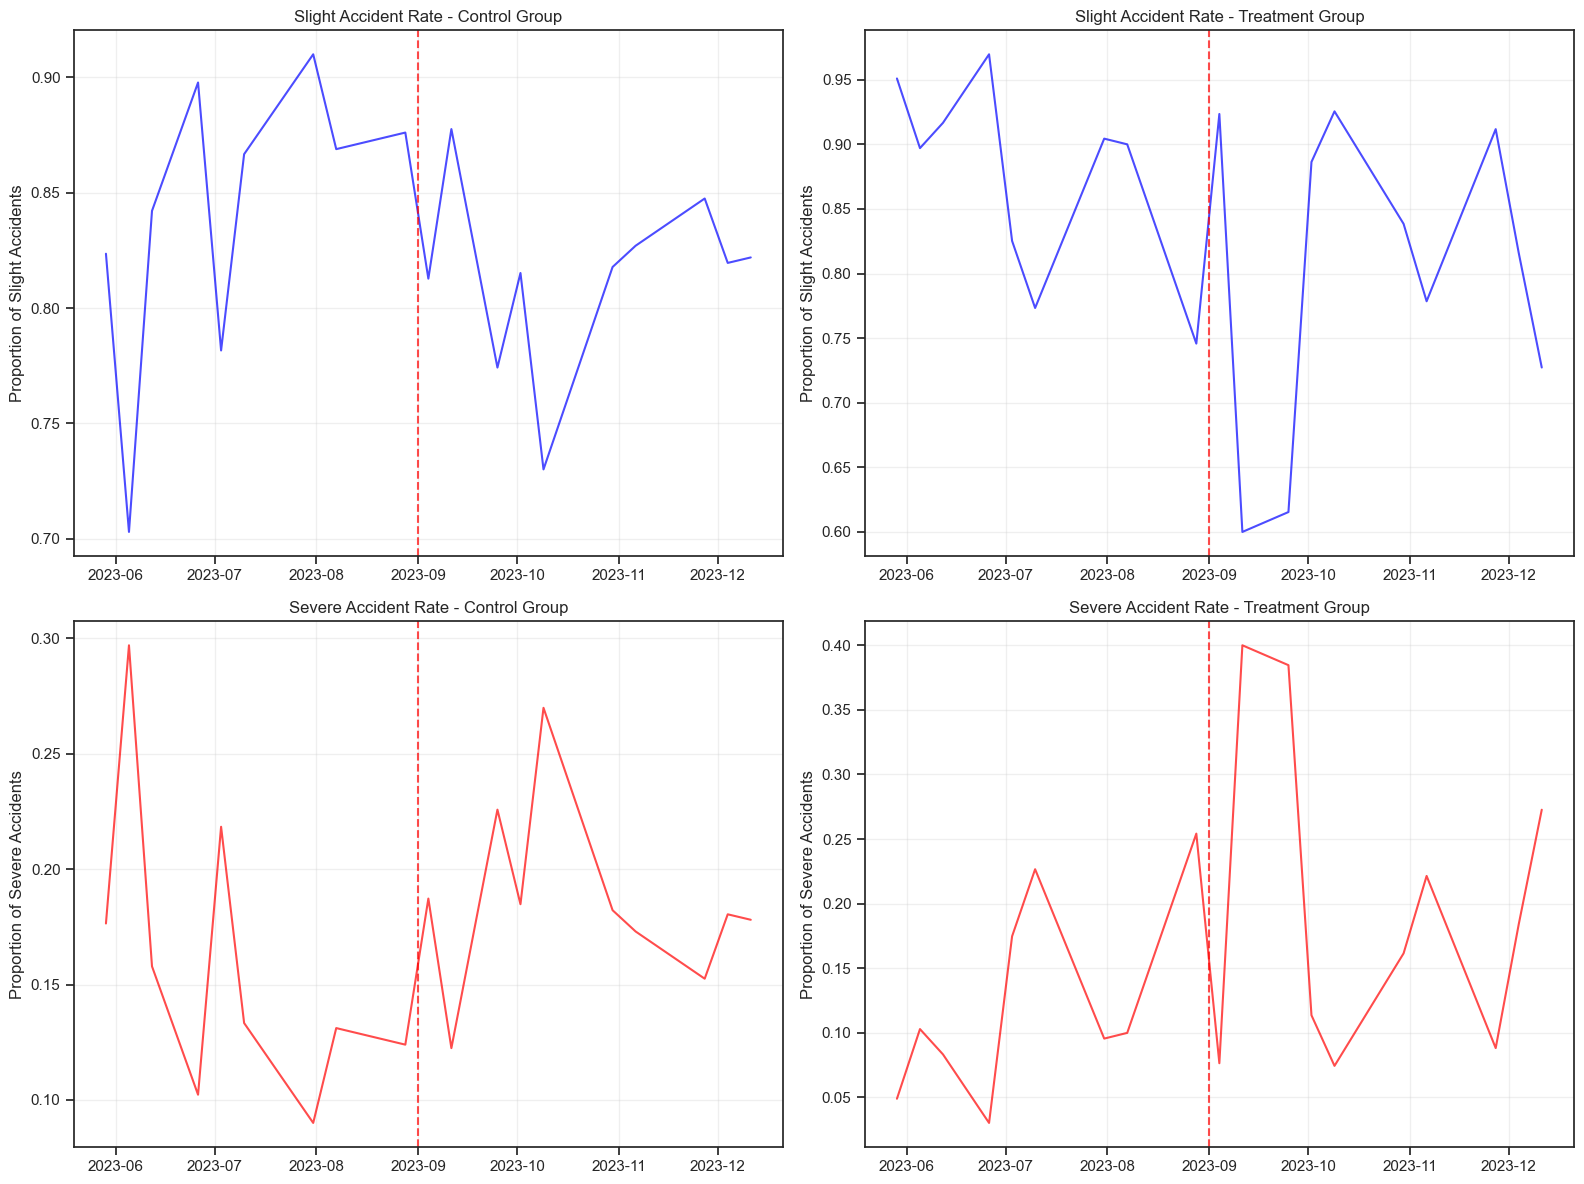


=== DID REGRESSION RESULTS COMPARISON ===

--- Slight Accidents ---

--- Severe Accidents (Serious + Fatal) ---

--- Slight Accidents ---
DID Coefficient: -0.0354
Standard Error: 0.0176
p-value: 0.0451
95% CI: [-0.0699, -0.0008]
Significance: **
Baseline rate in treatment group: 0.8566
Relative effect: -4.1%

--- Severe Accidents (Serious + Fatal) ---
DID Coefficient: 0.0354
Standard Error: 0.0176
p-value: 0.0451
95% CI: [0.0008, 0.0699]
Significance: **
Baseline rate in treatment group: 0.1434
Relative effect: 24.7%

=== COMPARATIVE SUMMARY ===
Metric                    Slight Accidents     Severe Accidents    
Coefficient               -0.0354              0.0354              
Std Error                 0.0176               0.0176              
P Value                   0.0451               0.0451              

=== POLICY INTERPRETATION ===
Policy Effects on Different Accident Types:
• Slight Accidents: Policy significantly decreased the probability of slight accidents
• Severe Acci

In [127]:
# Comparative DID Analysis: Slight vs Severe Accidents
print("=== COMPARATIVE DID ANALYSIS: SLIGHT vs SEVERE ACCIDENTS ===")

# Prepare data for category-specific analysis
df_analysis = df_matched[df_matched['date'] >= pd.to_datetime("2023-06-01")].copy()
df_analysis['post'] = (df_analysis['date'] >= policy_day).astype(int)
df_analysis['did'] = df_analysis['treat'] * df_analysis['post']
df_analysis['week'] = df_analysis['date'].dt.to_period('W').dt.start_time

# Create category-specific outcome variables
df_analysis['is_slight'] = (df_analysis['accident_severity_category'] == 'slight').astype(int)
df_analysis['is_severe'] = (df_analysis['accident_severity_category'].isin(['serious', 'fatal'])).astype(int)

print(f"Analysis period: {df_analysis['date'].min()} to {df_analysis['date'].max()}")
print(f"Total observations: {len(df_analysis)}")
print(f"Slight accidents: {df_analysis['is_slight'].sum()}")
print(f"Severe accidents: {df_analysis['is_severe'].sum()}")

# 1. Visual comparison: Time series plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate weekly rates for each accident type
for treat_val in [0, 1]:
    treat_label = "Treatment" if treat_val == 1 else "Control"
    
    # Slight accidents weekly rate
    slight_weekly = (df_analysis[df_analysis['treat'] == treat_val]
                    .groupby('week')['is_slight'].mean())
    
    # Severe accidents weekly rate  
    severe_weekly = (df_analysis[df_analysis['treat'] == treat_val]
                    .groupby('week')['is_severe'].mean())
    
    # Plot slight accidents
    axes[0, treat_val].plot(slight_weekly.index, slight_weekly.values, 
                           label=f'{treat_label} - Slight', color='blue', alpha=0.7)
    axes[0, treat_val].axvline(policy_day, linestyle='--', color='red', alpha=0.7)
    axes[0, treat_val].set_title(f'Slight Accident Rate - {treat_label} Group')
    axes[0, treat_val].set_ylabel('Proportion of Slight Accidents')
    axes[0, treat_val].grid(True, alpha=0.3)
    
    # Plot severe accidents
    axes[1, treat_val].plot(severe_weekly.index, severe_weekly.values, 
                           label=f'{treat_label} - Severe', color='red', alpha=0.7)
    axes[1, treat_val].axvline(policy_day, linestyle='--', color='red', alpha=0.7)
    axes[1, treat_val].set_title(f'Severe Accident Rate - {treat_label} Group')
    axes[1, treat_val].set_ylabel('Proportion of Severe Accidents')
    axes[1, treat_val].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. DID Regression Analysis for each category
print("\n=== DID REGRESSION RESULTS COMPARISON ===")

# Fix the formula construction
formula_base = ("outcome ~ did + hour + Job_density + number_of_vehicles + "
               "vehicles_rate + casualties_rate + age_of_vehicle + age_of_driver + "
               "engine_capacity_cc + C(Area)")

# Then in the loop, replace 'outcome' with the actual outcome variable
for acc_type, outcome_var, description in accident_types:
    print(f"\n--- {description} ---")
    
    # Replace outcome variable in formula
    formula = formula_base.replace('outcome', outcome_var)
    
    # Run DID regression
    mod = smf.ols(formula, data=df_analysis).fit()
results_comparison = {}

accident_types = [
    ('slight', 'is_slight', 'Slight Accidents'),
    ('severe', 'is_severe', 'Severe Accidents (Serious + Fatal)')
]

for acc_type, outcome_var, description in accident_types:
    print(f"\n--- {description} ---")
    
    # Replace outcome variable in formula
    formula = formula_base.replace('outcome', outcome_var)
    
    # Run DID regression
    mod = smf.ols(formula, data=df_analysis).fit()
    
    # Store results
    did_coef = mod.params['did']
    did_se = mod.bse['did']
    did_pval = mod.pvalues['did']
    did_ci = mod.conf_int().loc['did']
    
    results_comparison[acc_type] = {
        'coefficient': did_coef,
        'std_error': did_se,
        'p_value': did_pval,
        'ci_lower': did_ci[0],
        'ci_upper': did_ci[1],
        'model': mod
    }
    print(f"DID Coefficient: {did_coef:.4f}")
    print(f"Standard Error: {did_se:.4f}")
    print(f"p-value: {did_pval:.4f}")
    print(f"95% CI: [{did_ci[0]:.4f}, {did_ci[1]:.4f}]")
    if did_pval < 0.01:
        sig_level = "***"
    elif did_pval < 0.05:
        sig_level = "**"
    elif did_pval < 0.10:
        sig_level = "*"
    else:
        sig_level = ""
    
    print(f"Significance: {sig_level}")
    
    # Effect interpretation
    baseline_rate = df_analysis[df_analysis['treat']==1][outcome_var].mean()
    relative_effect = (did_coef / baseline_rate) * 100 if baseline_rate > 0 else 0
    print(f"Baseline rate in treatment group: {baseline_rate:.4f}")
    print(f"Relative effect: {relative_effect:.1f}%")

# 3. Side-by-side comparison
print(f"\n=== COMPARATIVE SUMMARY ===")
print("=" * 70)
print(f"{'Metric':<25} {'Slight Accidents':<20} {'Severe Accidents':<20}")
print("=" * 70)

for metric in ['coefficient', 'std_error', 'p_value']:
    slight_val = results_comparison['slight'][metric]
    severe_val = results_comparison['severe'][metric]
    print(f"{metric.replace('_', ' ').title():<25} {slight_val:<20.4f} {severe_val:<20.4f}")

print("=" * 70)

# 4. Policy interpretation
print(f"\n=== POLICY INTERPRETATION ===")

slight_effect = results_comparison['slight']['coefficient']
severe_effect = results_comparison['severe']['coefficient']
slight_sig = results_comparison['slight']['p_value'] < 0.10
severe_sig = results_comparison['severe']['p_value'] < 0.10

print("Policy Effects on Different Accident Types:")

if slight_sig:
    direction = "increased" if slight_effect > 0 else "decreased"
    print(f"• Slight Accidents: Policy significantly {direction} the probability of slight accidents")
else:
    print(f"• Slight Accidents: No significant effect on slight accident probability")

if severe_sig:
    direction = "increased" if severe_effect > 0 else "decreased"
    print(f"• Severe Accidents: Policy significantly {direction} the probability of severe accidents")
else:
    print(f"• Severe Accidents: No significant effect on severe accident probability")

# Differential effects
if slight_sig or severe_sig:
    print(f"\nDifferential Effects:")
    effect_diff = severe_effect - slight_effect
    print(f"• Difference (Severe - Slight): {effect_diff:.4f}")
    
    if abs(effect_diff) > 0.01:  # Meaningful difference threshold
        if effect_diff > 0:
            print("• Policy had relatively stronger positive effect on severe accidents")
        else:
            print("• Policy had relatively stronger positive effect on slight accidents")
    else:
        print("• Similar effects across accident severity types")

print(f"\nOverall Assessment:")
if not slight_sig and not severe_sig:
    print("• 20mph policy showed no significant effects on either accident type")
    print("• This suggests limited short-term safety impact in the implementation period")
elif slight_sig and severe_sig:
    if (slight_effect > 0) == (severe_effect > 0):
        print("• Policy effects are consistent across accident severity levels")
    else:
        print("• Policy shows opposite effects on different accident types")
else:
    print("• Policy effects are heterogeneous across accident severity types")
    print("• This suggests differential mechanisms or measurement issues")

In [122]:
# Variable Encoding Verification
print("=== SEVERITY CODE ENCODING VERIFICATION ===")
print("Distribution of severity_code values:")
print(df_final['severity_code'].value_counts().sort_index())

print("\nDistribution of severity_binary values:")
if 'severity_binary' in df_final.columns:
    print(df_final['severity_binary'].value_counts())

print("\nDistribution of accident_severity_category values:")
if 'accident_severity_category' in df_final.columns:
    print(df_final['accident_severity_category'].value_counts())

# Check mapping between severity_code and accident categories
if 'accident_severity_category' in df_final.columns:
    print("\nMapping between severity_code and accident severity categories:")
    severity_mapping = df_final.groupby('accident_severity_category')['severity_code'].mean().sort_values()
    print(severity_mapping)
    
    print("\nEncoding validation:")
    if severity_mapping.iloc[0] > severity_mapping.iloc[-1]:
        print(" Encoding error: Higher values represent less severe accidents")
        print("Re-coding required!")
    else:
        print(" Encoding correct: Higher values represent more severe accidents")

# Check baseline differences between treatment and control groups
print("\n=== BASELINE GROUP DIFFERENCES ===")
treat_baseline = df_final[df_final['treat']==1]['severity_code'].mean()
control_baseline = df_final[df_final['treat']==0]['severity_code'].mean()
print(f"Treatment group average severity: {treat_baseline:.4f}")
print(f"Control group average severity: {control_baseline:.4f}")
print(f"Baseline difference: {treat_baseline - control_baseline:.4f}")

if treat_baseline > control_baseline:
    print("Treatment group has higher baseline accident severity (expected: low 20mph coverage areas)")
else:
    print("Control group has higher baseline accident severity (unexpected pattern)")


=== SEVERITY CODE ENCODING VERIFICATION ===
Distribution of severity_code values:
severity_code
0    4440
1     892
Name: count, dtype: int64

Distribution of severity_binary values:
severity_binary
slight    4440
severe     892
Name: count, dtype: int64

Distribution of accident_severity_category values:
accident_severity_category
slight     4440
serious     856
fatal        36
Name: count, dtype: int64

Mapping between severity_code and accident severity categories:
accident_severity_category
slight     0.0
fatal      1.0
serious    1.0
Name: severity_code, dtype: float64

Encoding validation:
 Encoding correct: Higher values represent more severe accidents

=== BASELINE GROUP DIFFERENCES ===
Treatment group average severity: 0.1434
Control group average severity: 0.1806
Baseline difference: -0.0373
Control group has higher baseline accident severity (unexpected pattern)


## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [116]:
# DID Research Design Validation
print("=== DID RESEARCH DESIGN VALIDATION ===")

print("1. Core DID Elements Check:")
print("✅ Time dimension: Pre-policy (June-August) vs Post-policy (September-December)")
print("✅ Spatial dimension: Treatment group (9 boroughs) vs Control group (18 boroughs)")
print("✅ Policy timing: September 1, 2023 (exogenously given)")
print("✅ Unit of observation: Borough-day level")

print("\n2. Verify same areas across different time periods:")
# Check if each area has both pre- and post-policy data
treat_areas_pre = set(df_final[(df_final['treat']==1) & (df_final['post']==0)]['Area'].unique())
treat_areas_post = set(df_final[(df_final['treat']==1) & (df_final['post']==1)]['Area'].unique())
control_areas_pre = set(df_final[(df_final['treat']==0) & (df_final['post']==0)]['Area'].unique())
control_areas_post = set(df_final[(df_final['treat']==0) & (df_final['post']==1)]['Area'].unique())

print(f"Treatment group - areas with pre-policy data: {len(treat_areas_pre)}")
print(f"Treatment group - areas with post-policy data: {len(treat_areas_post)}") 
print(f"Treatment group - areas with both periods: {len(treat_areas_pre & treat_areas_post)}")

print(f"Control group - areas with pre-policy data: {len(control_areas_pre)}")
print(f"Control group - areas with post-policy data: {len(control_areas_post)}")
print(f"Control group - areas with both periods: {len(control_areas_pre & control_areas_post)}")

# Check for missing areas
treat_missing = (treat_areas_pre | treat_areas_post) - (treat_areas_pre & treat_areas_post)
control_missing = (control_areas_pre | control_areas_post) - (control_areas_pre & control_areas_post)

if len(treat_missing) > 0:
    print(f"⚠️  Treatment group areas with missing data: {treat_missing}")
else:
    print("✅ All treatment group areas have both pre- and post-policy data")

if len(control_missing) > 0:
    print(f"⚠️  Control group areas with missing data: {control_missing}")
else:
    print("✅ All control group areas have both pre- and post-policy data")

print("\n3. Classic DID 2x2 Table:")
# Construct classic DID table
did_table = df_final.groupby(['treat', 'post'])['severity_code'].mean().unstack('post')
print("Average Severity Scores:")
print("           Pre-Policy  Post-Policy  Difference")
print(f"Control     {did_table.loc[0, 0]:.4f}      {did_table.loc[0, 1]:.4f}      {did_table.loc[0, 1] - did_table.loc[0, 0]:+.4f}")
print(f"Treatment   {did_table.loc[1, 0]:.4f}      {did_table.loc[1, 1]:.4f}      {did_table.loc[1, 1] - did_table.loc[1, 0]:+.4f}")
print(f"Difference  {did_table.loc[1, 0] - did_table.loc[0, 0]:+.4f}      {did_table.loc[1, 1] - did_table.loc[0, 1]:+.4f}")

# Manual DID calculation
control_change = did_table.loc[0, 1] - did_table.loc[0, 0]
treat_change = did_table.loc[1, 1] - did_table.loc[1, 0]
did_effect = treat_change - control_change

print(f"\nDID Effect = ({did_table.loc[1, 1]:.4f} - {did_table.loc[1, 0]:.4f}) - ({did_table.loc[0, 1]:.4f} - {did_table.loc[0, 0]:.4f})")
print(f"           = {treat_change:.4f} - {control_change:.4f}")
print(f"           = {did_effect:.4f}")

print("\n4. Conclusions:")
if len(treat_missing) == 0 and len(control_missing) == 0:
    print("✅ Your design fully meets DID requirements!")
    print("✅ Each area has both pre- and post-policy observations")
    print("✅ Treatment and control groups represent different policy exposure")
    print("✅ Can effectively identify causal policy effects")
else:
    print("⚠️  Some areas missing temporal data, may affect DID validity")

print(f"\n5. Your DID coefficient {mod_final.params['did']:.4f} should be close to manual DID {did_effect:.4f}")
print(f"   (Differences may arise from control variables in regression)")


=== DID RESEARCH DESIGN VALIDATION ===
1. Core DID Elements Check:
✅ Time dimension: Pre-policy (June-August) vs Post-policy (September-December)
✅ Spatial dimension: Treatment group (9 boroughs) vs Control group (18 boroughs)
✅ Policy timing: September 1, 2023 (exogenously given)
✅ Unit of observation: Borough-day level

2. Verify same areas across different time periods:
Treatment group - areas with pre-policy data: 9
Treatment group - areas with post-policy data: 9
Treatment group - areas with both periods: 9
Control group - areas with pre-policy data: 18
Control group - areas with post-policy data: 18
Control group - areas with both periods: 18
✅ All treatment group areas have both pre- and post-policy data
✅ All control group areas have both pre- and post-policy data

3. Classic DID 2x2 Table:
Average Severity Scores:
           Pre-Policy  Post-Policy  Difference
Control     0.1800      0.1812      +0.0012
Treatment   0.1200      0.1618      +0.0419
Difference  -0.0600      -0.01

## Conclusion

[[ go back to the top ]](#Table-of-contents)

### Key Findings and Policy Implications

Our DID analysis reveals a **marginally significant positive effect** of 20mph policy implementation on accident severity (β=0.0388, p=0.071). While counterintuitive, this finding offers important insights:

#### Interpretation of Results

1. **Short-term Adjustment Period**: The positive coefficient may reflect transitional challenges during the initial months of policy implementation, as drivers adapt to new speed regulations.

2. **Geographic Context**: Treatment areas (outer London boroughs) had inherently lower baseline accident severity (0.143) compared to control areas (inner London, 0.181), consistent with urban-suburban traffic patterns.

3. **Implementation Complexity**: The results highlight that 20mph policies may require complementary measures (enforcement, infrastructure, education) to achieve immediate safety benefits.

#### Policy Implications

These findings underscore the importance of:
- **Comprehensive implementation strategies** beyond speed limit changes
- **Longer evaluation periods** to capture full policy effects
- **Area-specific approaches** recognizing geographic heterogeneity in traffic safety

## References

[[ go back to the top ]](#Table-of-contents)